[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/CA_Housing_Regression.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 7 (M2.2) - Prep California housing for a neural network

- Same California housing story as M1 - but this is the RAW CSV with a categorical column, so new wrangling: ocean_proximity needs get_dummies (5 categories), ~200 missing total_bedrooms rows get dropped.
- Neural networks need NUMBERS - a dot product can't multiply 'NEAR BAY'. That's WHY we one-hot encode.
- X/y split, 80/20, MinMaxScaler fit on TRAIN only - identical skeleton to M1, say so explicitly.
- Keep it <=8 min - the model comes next video.
-->

# NN Regression for CA Housing
-------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Let's go over a very basic notebook re: neural networks for regression using the CA Housing dataset (toy data).

# Set up your environment
Import modules, read data, explore data, data types, missing values etc.

In [1]:
# mount your drive on the left if needed

In [2]:
# import modules
# for general data analysis/plotting
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# for data prep
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# neural net modules
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

## Read from Google Drive with shareable link

In [3]:
# # https://drive.google.com/file/d/14cZCdu5PFog3RGcl_oryU9X8k0zQmeSS/view?usp=sharing
# !gdown 14cZCdu5PFog3RGcl_oryU9X8k0zQmeSS

In [4]:
# df = pd.read_csv('../data/CAhousing.csv')
# df.shape # 20640 rows and 10 columns

In [5]:
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module2_Files/data/CAhousing.csv"

# retrieve the CSV data and build a dataframe
df = pd.read_csv(url)

df.shape # 20640 rows and 10 columns

(20640, 10)

## Mount and read from Google Drive
CAHousing data is also part of the toy data from Google Colab - you can point to these data directly if you would like!

In [6]:
# # read in our dataset
# df = pd.read_csv('/content/drive/My Drive/OPIM 5509/Module 2: Dense Neural Networks/Data/CAhousing.csv')
# # download the dataset here: https://www.kaggle.com/camnugent/california-housing-prices

# EDA
Make sure you address any missing values before modeling, otherwise you will get an error! The loss values will be `NaN` if you try to build on model on dirty data with missing values.

## Variable data types

In [7]:
# we can see that there are a few missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## Missing Values

In [8]:
# drop any rows with missing values
df.dropna(axis=0, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.9 MB


## Categorical data
Delete it or recode it to dummy variables!
* https://www.marsja.se/how-to-use-pandas-get_dummies-to-create-dummy-variables-in-python/

Lots of nice examples here.

In [9]:
# check out ocean prox
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [10]:
# Creating dummy variables from one column:
df = pd.get_dummies(df, columns=['ocean_proximity'])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [11]:
df.shape

(20433, 14)

In [12]:
# #  delete character column
# del df['ocean_proximity']
# df.info()

# Prepare data for modeling
Split into X and y, minmax scaler (fit on X_train and apply to X_test)

In [13]:
# we know our target variable is 'median_house_value'
y = df['median_house_value']
X = df.drop('median_house_value', axis=1)
print(X.shape, y.shape)

(20433, 13) (20433,)


In [14]:
# convert to numpy array
X = np.array(X)
y = np.array(y)

In [15]:
# split into X_train and X_test
# always split into X_train, X_test first THEN apply minmax scaler
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=123)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(16346, 13) (4087, 13) (16346,) (4087,)


In [16]:
# use minMax scaler
min_max_scaler = MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 8 (M2.2) - Build, compile, fit (and early stopping)

- The big moment: model = Sequential(), stack Dense layers, ReLU hidden + LINEAR output (regression wants any value).
- input_shape=(features,) - explain the trailing comma once, calmly (the None is the batch dimension).
- Compile = optimizer (Adam/RMSprop), loss (MSE), metrics (MAE - it's in dollars, people understand it).
- Early stopping with restore_best_weights beats guessing an epoch count: stop when val_loss stops improving, keep the best model.
- Fit with validation_data and watch it train live - narrate the loss falling.
-->

# Build, compile, fit model
Use the Sequential API to build your model; specify an optimizer (rmsprop or adam) and a loss function (mse or mae); then fit your model (make a new variable called 'history' so you can evaluate the learning curves). We'll use EarlyStopping callbacks to prevent overfitting (patience of 5).

In [17]:
# rather than hardcoding the input shape, I like to use this instead - more elegant
# helps you hack/copy paste your code later on
X_train.shape[1]

13

Don't forget an activation function in each layer!
* `relu` in the dense layers to recode negative numbers to 0 (introduces nonlinearity which is so important!)
* `linear` (default) in the output layer so that output can range from -Inf to Inf

## Build

In [18]:
# build the model!
model = Sequential()
model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu')) # (features,)
model.add(Dense(25, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear')) # output node
model.summary() # see what your model looks like

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,246 (8.77 KB)

 Trainable params: 2,246 (8.77 KB)

 Non-trainable params: 0 (0.00 B)

### ... visualize...

In [19]:
import tensorflow as tf
tf.keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [20]:
!pip install keras-visualizer


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\dww05002\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
from keras_visualizer import visualizer
# look left! graph.png in local folder
try:
    visualizer(model, file_format='png', view=True)
except Exception as e:
    # renders fine on Colab (graphviz preinstalled); on a bare machine install graphviz first
    print('keras_visualizer needs the graphviz binary to draw the png -', e)

keras_visualizer needs the graphviz binary to draw the png - [Keras Visualizer] Error while visualizing: <class 'Exception'>


In [22]:
# view it
from IPython.display import Image
import os

# 'graph.png' in the left-hand side folder icon
image_path = 'graph.png'

# Display the image in the notebook (only exists if the visualizer cell above rendered)
Image(filename=image_path) if os.path.exists(image_path) else print('graph.png not found - the visualizer cell above renders it on Colab')

graph.png not found - the visualizer cell above renders it on Colab


## Compile
Choose your optimizer, loss function to minimize, and the metrics you'd like to track while training!
* optimizer (more here: https://keras.io/api/optimizers/):
  * SGD
  * RMSprop
  * Adam
  * Adadelta
* loss (more here: https://keras.io/api/losses/):
  * MeanSquaredError
  * MeanAbsoluteError
  * MeanAbsolutePercentageError
  * MeanSquaredLogarithmicError
* metrics (optional to use, more here: https://keras.io/api/metrics/regression_metrics/):
  * same as metrics listed for loss function

In [23]:
# compile the model
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

## Callbacks/Early Stopping
This is optional, but you should use this early stopping callback! It prevents you from overfitting or underfitting and returns the best weights... why wouldn't you do this every time?!

In [24]:
# early stopping callback
es = EarlyStopping(monitor='val_loss',
                   mode='min',
                   patience=5, # you can choose a big value!
                   restore_best_weights = True) # don't forget this! otherwise it's potentially suboptimal weights

## Fit the model
And save the output in the variable called `history` so you can plot the loss curves and monitor model training.

A quick note on validation data - the code below specifies a validation dataset to monitor while you are training. I often find that companies prefer you to use the `validation_split` parameter with `shuffle=True` and then test the model on the holdout data. This way you don't have a pulse on how the model would fit on the test data - looks less like data leakage.

In [25]:
# # resets names in the model summary
# from keras import backend as K
# K.clear_session()

In [26]:
# fit the model!
# remember, assign it to a new variable called 'history' in case
# we want to look at the learning curves

history = model.fit(X_train, y_train,
                    validation_data = (X_test, y_test),
                    callbacks=[es], # early stopping callbacks
                    epochs=5000, # set this to a big number
                    batch_size=50, # this is a hyperparameter
                    shuffle=True, # it's a best practice to shuffle your data
                    verbose=1) # this prints the output as the model trains

Epoch 1/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 5:48 1s/step - loss: 52411912192.0000 - mae: 195702.0469

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55871430656.0000 - mae: 205804.4375 

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55748288512.0000 - mae: 206187.0156

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56512204800.0000 - mae: 207075.0156

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56726212608.0000 - mae: 207589.0312

166/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56301740032.0000 - mae: 206786.8125

198/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56022872064.0000 - mae: 206205.4844

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55808397312.0000 - mae: 205927.5000

260/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55959646208.0000 - mae: 206303.3125

292/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56005230592.0000 - mae: 206442.8594

325/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56319057920.0000 - mae: 207081.5625

327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 56329728000.0000 - mae: 207077.3906 - val_loss: 54780514304.0000 - val_mae: 204843.5000


Epoch 2/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 64450220032.0000 - mae: 222126.9219

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56197836800.0000 - mae: 206436.8281  

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56176771072.0000 - mae: 206510.0312

 86/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56526106624.0000 - mae: 207248.4688

116/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56184381440.0000 - mae: 206624.3906

148/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55954845696.0000 - mae: 206309.2344

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55513051136.0000 - mae: 205468.2969

205/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55684186112.0000 - mae: 205750.5625

237/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55787220992.0000 - mae: 205841.1719

268/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55830884352.0000 - mae: 205832.7812

297/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55616258048.0000 - mae: 205343.4375

327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55403462656.0000 - mae: 204843.0781

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 55403462656.0000 - mae: 204843.0781 - val_loss: 52818763776.0000 - val_mae: 200047.5000


Epoch 3/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 46023835648.0000 - mae: 190178.0469

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55362617344.0000 - mae: 204054.9219  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54438182912.0000 - mae: 202572.0156

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 52914798592.0000 - mae: 198926.7188

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53109186560.0000 - mae: 198889.5000

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53046317056.0000 - mae: 198675.2656

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 52875661312.0000 - mae: 198465.5625

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 52409704448.0000 - mae: 197474.7188

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 51957170176.0000 - mae: 196387.1094

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 51891675136.0000 - mae: 196066.1875

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 51466952704.0000 - mae: 195122.3125

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 51492024320.0000 - mae: 195139.7500 - val_loss: 46581805056.0000 - val_mae: 183991.6250


Epoch 4/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 39104950272.0000 - mae: 173813.3750

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47190659072.0000 - mae: 184193.5469  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45325938688.0000 - mae: 180019.9062

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 46199816192.0000 - mae: 181648.7031

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45646827520.0000 - mae: 179728.5938

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45119623168.0000 - mae: 178429.3438

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44941877248.0000 - mae: 177527.4531

215/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44220116992.0000 - mae: 175746.7656

246/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 43668660224.0000 - mae: 174106.5000

273/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 43058110464.0000 - mae: 172346.6875

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42556370944.0000 - mae: 170864.3594

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 42079514624.0000 - mae: 169478.9531 - val_loss: 34094147584.0000 - val_mae: 147120.4219


Epoch 5/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 52298326016.0000 - mae: 188811.5000

 21/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35536367616.0000 - mae: 149849.1875 

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 33192785920.0000 - mae: 142880.1875

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32696285184.0000 - mae: 141112.1094

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32132069376.0000 - mae: 138927.8750

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 31442305024.0000 - mae: 136563.7344

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30357067776.0000 - mae: 133363.9844

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29425750016.0000 - mae: 130453.9609

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 28525699072.0000 - mae: 127980.0625

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27927764992.0000 - mae: 125994.5391

315/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27331289088.0000 - mae: 124202.6875

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27024232448.0000 - mae: 123286.6875 - val_loss: 18148206592.0000 - val_mae: 96353.5391


Epoch 6/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 22274334720.0000 - mae: 107686.0391

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19638519808.0000 - mae: 100250.2188 

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18251317248.0000 - mae: 96706.2266 

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17528670208.0000 - mae: 94400.2344

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16550927360.0000 - mae: 91808.8438

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15883966464.0000 - mae: 90694.1641

201/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15243467776.0000 - mae: 89265.4141

231/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14884818944.0000 - mae: 88681.3984

261/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14596054016.0000 - mae: 88281.1953

297/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14356304896.0000 - mae: 88203.0938

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14077253632.0000 - mae: 87840.4219 - val_loss: 11174326272.0000 - val_mae: 82852.9531


Epoch 7/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 12353133568.0000 - mae: 95780.9375

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12236410880.0000 - mae: 87328.6250  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11802124288.0000 - mae: 85929.7969

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11591782400.0000 - mae: 85243.1328

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11533273088.0000 - mae: 85013.2109

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11471702016.0000 - mae: 85021.3438

183/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11386697728.0000 - mae: 84686.6250

215/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11394068480.0000 - mae: 84613.6797

244/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11399912448.0000 - mae: 84652.1719

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11299588096.0000 - mae: 84283.3984

310/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11311385600.0000 - mae: 84313.0078

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11287330816.0000 - mae: 84145.4297 - val_loss: 10390937600.0000 - val_mae: 81163.0312


Epoch 8/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 13223511040.0000 - mae: 96816.6484

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11054574592.0000 - mae: 84042.3438  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10806066176.0000 - mae: 82959.9531

103/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10875835392.0000 - mae: 82953.8828

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10836880384.0000 - mae: 82682.5078

165/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10718094336.0000 - mae: 82026.7109

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10679417856.0000 - mae: 81859.2578

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10648351744.0000 - mae: 81819.9766

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10622901248.0000 - mae: 81813.4609

277/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10541605888.0000 - mae: 81508.2344

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10491675648.0000 - mae: 81375.9453

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10519157760.0000 - mae: 81418.0547

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10519922688.0000 - mae: 81383.6562 - val_loss: 9696556032.0000 - val_mae: 77992.2891


Epoch 9/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 9331243008.0000 - mae: 78542.7734

 22/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10509705216.0000 - mae: 81685.0312 

 43/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10476470272.0000 - mae: 81976.5859

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10274275328.0000 - mae: 80998.3828

 86/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10454506496.0000 - mae: 81395.2344

108/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10339366912.0000 - mae: 81057.1328

130/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10375784448.0000 - mae: 81143.2266

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10239803392.0000 - mae: 80594.1719

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10079596544.0000 - mae: 79810.9062

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10012126208.0000 - mae: 79401.4609

243/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9966385152.0000 - mae: 79175.5703 

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9890758656.0000 - mae: 78788.0469

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9846177792.0000 - mae: 78512.2344

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9859827712.0000 - mae: 78577.1562 - val_loss: 9112359936.0000 - val_mae: 75027.4609


Epoch 10/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 10952936448.0000 - mae: 85599.1094

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9373066240.0000 - mae: 76664.7656   

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9668038656.0000 - mae: 78145.0391

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9508013056.0000 - mae: 76917.9922

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9240314880.0000 - mae: 75841.8125

171/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9328838656.0000 - mae: 76147.4531

197/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9353899008.0000 - mae: 76222.6328

225/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9295341568.0000 - mae: 75999.0312

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9282496512.0000 - mae: 75946.4531

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9290212352.0000 - mae: 75901.4141

312/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9304503296.0000 - mae: 76001.6953

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9300475904.0000 - mae: 75979.3828 - val_loss: 8632138752.0000 - val_mae: 72665.9297


Epoch 11/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 9620952064.0000 - mae: 78389.4688

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8860092416.0000 - mae: 74573.0078  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8837067776.0000 - mae: 74196.3281

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8932834304.0000 - mae: 74447.6875

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8994927616.0000 - mae: 74552.8984

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8925944832.0000 - mae: 74184.3750

176/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8903050240.0000 - mae: 74167.8750

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8923423744.0000 - mae: 74181.7344

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8852873216.0000 - mae: 73875.2500

244/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8934219776.0000 - mae: 74101.8672

272/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8906177536.0000 - mae: 73968.5391

302/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8908141568.0000 - mae: 73927.4375

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8843425792.0000 - mae: 73615.6172 - val_loss: 8253142528.0000 - val_mae: 70270.7812


Epoch 12/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - loss: 5747090432.0000 - mae: 57757.7461

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8447429632.0000 - mae: 71405.4219  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8656950272.0000 - mae: 72215.6406

 87/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8656146432.0000 - mae: 72649.7656

117/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8682829824.0000 - mae: 72802.0469

146/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8573923840.0000 - mae: 72218.7422

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8544004096.0000 - mae: 72103.4688

205/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8519583232.0000 - mae: 71921.6953

241/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8550098944.0000 - mae: 71959.0469

271/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8522911744.0000 - mae: 71704.1953

301/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8502383616.0000 - mae: 71594.3203

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8499719168.0000 - mae: 71594.4453 - val_loss: 7977051648.0000 - val_mae: 69026.5781


Epoch 13/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 7996704768.0000 - mae: 63540.6602

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8134199808.0000 - mae: 70379.2266 

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8050170880.0000 - mae: 69340.7578

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8358983168.0000 - mae: 70543.1406

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8278875136.0000 - mae: 70316.1328

165/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8354065408.0000 - mae: 70602.8359

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8297706496.0000 - mae: 70454.2344

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8306318848.0000 - mae: 70477.3750

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8207764480.0000 - mae: 70126.4688

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8202718720.0000 - mae: 70027.7500

323/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8224512000.0000 - mae: 70105.6719

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8231204352.0000 - mae: 70091.4609 - val_loss: 7745724416.0000 - val_mae: 67470.2656


Epoch 14/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 10639075328.0000 - mae: 79644.2578

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8121074176.0000 - mae: 70260.3594  

 59/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8074753024.0000 - mae: 69329.3516

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7950078464.0000 - mae: 68689.2109

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8002632704.0000 - mae: 68731.6562

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8040852480.0000 - mae: 69016.0859

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8042180608.0000 - mae: 69043.5859

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8068628480.0000 - mae: 69198.2422

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8063331328.0000 - mae: 69024.8594

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8056294400.0000 - mae: 69018.2266

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8028787200.0000 - mae: 68922.4609

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7998556672.0000 - mae: 68810.7578 - val_loss: 7538982912.0000 - val_mae: 66695.8906


Epoch 15/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 8973450240.0000 - mae: 72396.5000

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7898275840.0000 - mae: 68449.7734 

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7686145536.0000 - mae: 67763.9062

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7610049024.0000 - mae: 67249.7188

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7651803648.0000 - mae: 67446.8984

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7733333504.0000 - mae: 67598.4297

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7817436160.0000 - mae: 67944.3828

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7777211392.0000 - mae: 67680.1016

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7704937984.0000 - mae: 67294.0469

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7762384896.0000 - mae: 67520.2266

315/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7807975936.0000 - mae: 67800.4141

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7777235968.0000 - mae: 67701.5469 - val_loss: 7325245952.0000 - val_mae: 65130.9648


Epoch 16/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 6455401472.0000 - mae: 57021.1992

 23/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7740249088.0000 - mae: 68082.8438 

 53/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7707452928.0000 - mae: 67434.9609

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7519269376.0000 - mae: 66647.4062

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7542859776.0000 - mae: 66776.6406

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7454555648.0000 - mae: 66475.8281

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7445721600.0000 - mae: 66270.8984

231/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7498673152.0000 - mae: 66498.1641

262/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7539422720.0000 - mae: 66530.1719

295/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7534781952.0000 - mae: 66491.7812

326/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7566823424.0000 - mae: 66509.2109

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7562917888.0000 - mae: 66488.7109 - val_loss: 7137237504.0000 - val_mae: 64801.9805


Epoch 17/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 5841265664.0000 - mae: 54987.9961

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7670621696.0000 - mae: 67466.0859  

 72/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7521568256.0000 - mae: 66804.7812

102/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7447095296.0000 - mae: 66052.7578

135/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7405755904.0000 - mae: 65691.0234

165/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7259426304.0000 - mae: 65217.3789

197/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7305223168.0000 - mae: 65377.9414

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7360757248.0000 - mae: 65597.7969

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7318756864.0000 - mae: 65350.4648

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7336417792.0000 - mae: 65439.4102

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7349775360.0000 - mae: 65487.9258 - val_loss: 6910912512.0000 - val_mae: 63102.5625


Epoch 18/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 9824720896.0000 - mae: 74433.5078

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6780646912.0000 - mae: 62546.9453  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7186907648.0000 - mae: 64517.7305

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7241451520.0000 - mae: 64687.7070

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7190717952.0000 - mae: 64492.2031

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7169632768.0000 - mae: 64410.5703

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7255349248.0000 - mae: 64765.3477

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7258423808.0000 - mae: 64849.5508

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7294942208.0000 - mae: 65043.4102

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7229630464.0000 - mae: 64761.4883

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7129467392.0000 - mae: 64312.2891 - val_loss: 6712240640.0000 - val_mae: 61515.1875


Epoch 19/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 9997583360.0000 - mae: 73152.1328

 21/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7840331776.0000 - mae: 66031.4141 

 50/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7032615424.0000 - mae: 63488.9023

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6860761088.0000 - mae: 63072.0938

119/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6778269696.0000 - mae: 62675.3984

149/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6722864640.0000 - mae: 62338.9492

177/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6789453824.0000 - mae: 62639.3320

225/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6892444160.0000 - mae: 62867.4062

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6917909504.0000 - mae: 63005.6055

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6966918656.0000 - mae: 63262.3242

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6922500096.0000 - mae: 63137.3867

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6917036544.0000 - mae: 63095.9336 - val_loss: 6506309120.0000 - val_mae: 60834.5508


Epoch 20/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 8177478656.0000 - mae: 68328.9766

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7127344128.0000 - mae: 64132.4688  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7176210944.0000 - mae: 64218.0000

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7147617280.0000 - mae: 63992.2773

116/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6953119744.0000 - mae: 63376.3320

146/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6865264128.0000 - mae: 62896.0703

178/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6901065728.0000 - mae: 63104.7969

208/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6852619264.0000 - mae: 62963.2969

240/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6775802368.0000 - mae: 62574.3359

271/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6729689088.0000 - mae: 62204.7305

300/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6700048384.0000 - mae: 62025.5703

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6705115648.0000 - mae: 61936.5742 - val_loss: 6307037696.0000 - val_mae: 60000.5352


Epoch 21/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 5005059072.0000 - mae: 55680.2266

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6271716864.0000 - mae: 60287.6953  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6252989440.0000 - mae: 59865.3711

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6436419584.0000 - mae: 60603.8984

136/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6434351616.0000 - mae: 60634.7773

168/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6535864320.0000 - mae: 61092.7109

199/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6565282816.0000 - mae: 61131.0391

229/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6556022272.0000 - mae: 61142.0898

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6544284672.0000 - mae: 60984.9961

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6515159552.0000 - mae: 60884.4766

324/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6488729088.0000 - mae: 60724.5078

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6487843328.0000 - mae: 60732.6523 - val_loss: 6128042496.0000 - val_mae: 59542.7812


Epoch 22/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 4198620928.0000 - mae: 53532.8867

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6316108288.0000 - mae: 60161.6875  

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6109765632.0000 - mae: 58864.9375

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6153330688.0000 - mae: 59084.0391

130/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6295508480.0000 - mae: 59635.6953

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6295422464.0000 - mae: 59713.4375

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6374336000.0000 - mae: 60066.4141

219/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6374646272.0000 - mae: 59980.3203

251/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6329101312.0000 - mae: 59712.8477

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6274712576.0000 - mae: 59498.1680

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6295644672.0000 - mae: 59607.9023

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6288701952.0000 - mae: 59582.4688 - val_loss: 5923821056.0000 - val_mae: 57885.6484


Epoch 23/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 7338489344.0000 - mae: 61100.3945

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6477362688.0000 - mae: 60103.5859  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6295301120.0000 - mae: 59358.3125

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6294162432.0000 - mae: 59281.3086

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6184237056.0000 - mae: 59090.2812

153/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6081168384.0000 - mae: 58666.1719

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6024009728.0000 - mae: 58411.9297

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6079774720.0000 - mae: 58580.7188

246/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6089934336.0000 - mae: 58501.0938

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6138323968.0000 - mae: 58712.1680

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6146563072.0000 - mae: 58634.0781

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6099450368.0000 - mae: 58420.3750 - val_loss: 5760954880.0000 - val_mae: 56966.3320


Epoch 24/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 3965118464.0000 - mae: 49084.7031

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5809737216.0000 - mae: 56508.5586  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5995809280.0000 - mae: 57653.2734

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6071554048.0000 - mae: 57888.3516

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5983225856.0000 - mae: 57529.8867

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5928742400.0000 - mae: 57312.2539

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5857478144.0000 - mae: 56864.6055

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5868817408.0000 - mae: 57014.1562

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5893890048.0000 - mae: 57119.6875

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5892191232.0000 - mae: 57178.4336

325/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5928477696.0000 - mae: 57361.3477

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5930961920.0000 - mae: 57359.5625 - val_loss: 5605386752.0000 - val_mae: 55797.9375


Epoch 25/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 5691537408.0000 - mae: 56276.4219

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5652909056.0000 - mae: 55661.0898  

 70/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5825250304.0000 - mae: 56564.1953

103/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5808982528.0000 - mae: 56653.1367

134/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5749831168.0000 - mae: 56457.6094

165/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5852674048.0000 - mae: 56756.9727

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5785993728.0000 - mae: 56525.2109

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5789337088.0000 - mae: 56528.5273

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5786894848.0000 - mae: 56527.7109

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5765570048.0000 - mae: 56386.8320

326/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5787549184.0000 - mae: 56441.7344

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5782942208.0000 - mae: 56425.5938 - val_loss: 5477540864.0000 - val_mae: 54913.3359


Epoch 26/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 7778816000.0000 - mae: 61153.2500

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5918669824.0000 - mae: 57734.5391  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6076311040.0000 - mae: 57468.2383

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5985421312.0000 - mae: 57226.5078

134/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5884389376.0000 - mae: 56665.8047

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5762326528.0000 - mae: 56085.2617

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5751781888.0000 - mae: 55997.7812

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5779450368.0000 - mae: 56191.2539

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5753371136.0000 - mae: 56084.0039

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5753635328.0000 - mae: 56002.4141

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5680606208.0000 - mae: 55671.6367

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5661060608.0000 - mae: 55612.2539 - val_loss: 5371267072.0000 - val_mae: 53883.7891


Epoch 27/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 5495183872.0000 - mae: 52359.3281

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5503737344.0000 - mae: 54033.6289  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5391306752.0000 - mae: 53874.5273

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5625241600.0000 - mae: 55123.5469

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5543758336.0000 - mae: 54817.1914

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5618272256.0000 - mae: 54892.4727

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5606221824.0000 - mae: 54857.2383

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5647195136.0000 - mae: 55232.2773

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5648133120.0000 - mae: 55318.0430

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5617980416.0000 - mae: 55149.7070

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5580110848.0000 - mae: 54999.8555

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5560361984.0000 - mae: 54888.1914 - val_loss: 5288281600.0000 - val_mae: 53542.2344


Epoch 28/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 6351332864.0000 - mae: 63281.1406

 25/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5438235648.0000 - mae: 54531.5117  

 55/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5571515904.0000 - mae: 54838.0039

 86/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5702812672.0000 - mae: 55408.1914

115/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5613534720.0000 - mae: 55205.2852

147/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5560854528.0000 - mae: 55031.7031

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5546933248.0000 - mae: 54807.7773

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5584959488.0000 - mae: 54872.5312

245/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5538243072.0000 - mae: 54649.7344

277/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5531204608.0000 - mae: 54586.0312

315/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5508969472.0000 - mae: 54509.1445

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5479881728.0000 - mae: 54328.0430 - val_loss: 5226451968.0000 - val_mae: 53369.8867


Epoch 29/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 8895721472.0000 - mae: 69431.2031

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5539694080.0000 - mae: 53465.8711  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5725913088.0000 - mae: 54577.4883

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5575123968.0000 - mae: 54482.2656

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5524676096.0000 - mae: 54213.2578

153/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5421481472.0000 - mae: 53735.9453

183/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5384963072.0000 - mae: 53755.0742

222/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5429724672.0000 - mae: 53846.8594

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5407072768.0000 - mae: 53800.0859

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5451105792.0000 - mae: 54012.1016

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5432737792.0000 - mae: 53997.4648

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5417671168.0000 - mae: 53961.1055 - val_loss: 5172050432.0000 - val_mae: 52724.7812


Epoch 30/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 3969587968.0000 - mae: 46960.6641

 39/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5590694400.0000 - mae: 55046.6328  

 72/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5469303808.0000 - mae: 54509.7422

103/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5399574016.0000 - mae: 54126.9062

140/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5338180096.0000 - mae: 53614.1953

180/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5316722688.0000 - mae: 53310.8750

210/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5271045120.0000 - mae: 53152.8359

242/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5302428672.0000 - mae: 53205.0820

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5317281280.0000 - mae: 53328.1953

306/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5376375296.0000 - mae: 53591.2617

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5367308288.0000 - mae: 53537.2617 - val_loss: 5136925184.0000 - val_mae: 52670.3281


Epoch 31/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 5256460800.0000 - mae: 52558.8242

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5191730688.0000 - mae: 52215.3594  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5245567488.0000 - mae: 52455.0547

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5229000704.0000 - mae: 52437.2031

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5220539904.0000 - mae: 52535.5742

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5246215680.0000 - mae: 52754.1289

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5276919808.0000 - mae: 53037.1328

222/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5316535296.0000 - mae: 53200.4570

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5386550272.0000 - mae: 53454.3320

292/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5357432320.0000 - mae: 53378.4141

323/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5346006528.0000 - mae: 53317.7617

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5333209600.0000 - mae: 53268.2109 - val_loss: 5102019584.0000 - val_mae: 52026.3125


Epoch 32/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 3709036544.0000 - mae: 43237.3438

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5025704448.0000 - mae: 52347.1602  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5196370944.0000 - mae: 52811.3008

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5328103424.0000 - mae: 53176.3945

119/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5246000128.0000 - mae: 52753.1289

145/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5256751104.0000 - mae: 52690.3359

173/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5241213440.0000 - mae: 52826.0273

201/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5279263232.0000 - mae: 53037.0742

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5303703552.0000 - mae: 53135.5859

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5314204672.0000 - mae: 53145.0547

285/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5291645952.0000 - mae: 52936.9844

315/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5283406848.0000 - mae: 52876.2461

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5304918528.0000 - mae: 52974.6875 - val_loss: 5099163136.0000 - val_mae: 52710.2695


Epoch 33/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 3637011456.0000 - mae: 45906.5547

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5280854528.0000 - mae: 53548.4805  

 55/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5221669888.0000 - mae: 53102.6484

 87/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5353354240.0000 - mae: 53412.7148

116/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5369300480.0000 - mae: 53521.5000

145/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5325436416.0000 - mae: 53385.5430

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5335214592.0000 - mae: 53381.2188

203/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5285908480.0000 - mae: 53166.5781

232/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5292887552.0000 - mae: 53271.8516

270/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5265647104.0000 - mae: 53091.0898

302/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5266549760.0000 - mae: 52932.0898

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5283921920.0000 - mae: 52885.5742 - val_loss: 5063956480.0000 - val_mae: 52034.5234


Epoch 34/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 5367053824.0000 - mae: 50975.6406

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5181538816.0000 - mae: 52659.5781  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5224073728.0000 - mae: 52937.8594

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5389381120.0000 - mae: 53485.0000

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5484047872.0000 - mae: 53794.6172

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5510129664.0000 - mae: 54006.3594

177/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5435783680.0000 - mae: 53796.2344

206/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5397365760.0000 - mae: 53519.9453

232/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5388207104.0000 - mae: 53417.6680

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5348609536.0000 - mae: 53264.5586

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5349642240.0000 - mae: 53317.3516

298/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5319492096.0000 - mae: 53115.4609

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5266738688.0000 - mae: 52801.8555

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5265673728.0000 - mae: 52754.1602 - val_loss: 5046240256.0000 - val_mae: 51614.8906


Epoch 35/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 6954043904.0000 - mae: 50342.0508

 19/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5573061120.0000 - mae: 51776.9141  

 41/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5426194944.0000 - mae: 52300.3164

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5411590656.0000 - mae: 52825.2852

 88/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5358612480.0000 - mae: 52700.3672

115/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5382487040.0000 - mae: 53014.0234

137/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5411980288.0000 - mae: 53212.4766

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5346142720.0000 - mae: 52989.4453

181/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5324233216.0000 - mae: 52808.5742

201/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5293899264.0000 - mae: 52788.4688

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5248574976.0000 - mae: 52686.6211

243/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5215823360.0000 - mae: 52535.8672

266/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5208248832.0000 - mae: 52461.6289

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5206584320.0000 - mae: 52504.9375

313/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5252577792.0000 - mae: 52594.2930

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5251676672.0000 - mae: 52576.9609 - val_loss: 5032837632.0000 - val_mae: 51770.0156


Epoch 36/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 4786951168.0000 - mae: 51650.9219

 20/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5196137472.0000 - mae: 52372.6680  

 41/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5402189312.0000 - mae: 52628.8203

 57/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5543574016.0000 - mae: 53599.7305

 79/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5393344512.0000 - mae: 52849.8008

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5477682176.0000 - mae: 53122.2109

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5454807552.0000 - mae: 53289.7773

146/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5443807744.0000 - mae: 53388.6719

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5350121472.0000 - mae: 52989.1406

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5278671872.0000 - mae: 52629.9688

205/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5314070016.0000 - mae: 52765.0273

230/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5328017920.0000 - mae: 52873.9961

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5284447232.0000 - mae: 52751.9805

274/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5307980288.0000 - mae: 52802.9297

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5244511744.0000 - mae: 52575.4258

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5235112448.0000 - mae: 52500.3906 - val_loss: 5031398400.0000 - val_mae: 52035.5977


Epoch 37/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 6664206336.0000 - mae: 63198.7109

 20/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5359555584.0000 - mae: 53430.2656 

 49/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5304203776.0000 - mae: 53229.2500

 77/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5234811392.0000 - mae: 52135.1758

104/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5218339840.0000 - mae: 52223.9023

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5300075520.0000 - mae: 52431.9492

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5264347648.0000 - mae: 52367.9961

178/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5266845184.0000 - mae: 52597.1367

205/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5291896320.0000 - mae: 52594.5625

232/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5282043904.0000 - mae: 52589.4805

261/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5321114112.0000 - mae: 52819.4883

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5243556352.0000 - mae: 52558.2812

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5222608384.0000 - mae: 52384.8828 - val_loss: 5019108864.0000 - val_mae: 51974.9648


Epoch 38/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 5637527552.0000 - mae: 55506.2031

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5235003904.0000 - mae: 52197.3477  

 59/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5127808000.0000 - mae: 51527.2031

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5234892288.0000 - mae: 51914.2305

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5161704448.0000 - mae: 51975.1484

155/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5291034112.0000 - mae: 52754.0742

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5166852096.0000 - mae: 52316.7773

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5182477824.0000 - mae: 52380.4805

249/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5209043456.0000 - mae: 52520.0859

279/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5197995008.0000 - mae: 52399.7188

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5190601216.0000 - mae: 52325.5547

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5213191680.0000 - mae: 52375.9219 - val_loss: 4994942976.0000 - val_mae: 51405.2500


Epoch 39/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 5974006784.0000 - mae: 54697.5195

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4891623424.0000 - mae: 49616.5352  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5298775552.0000 - mae: 51808.8203

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5145638400.0000 - mae: 51544.2773

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5233432064.0000 - mae: 52033.5742

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5216139264.0000 - mae: 52162.5352

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5215805440.0000 - mae: 52359.9844

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5231288320.0000 - mae: 52431.9961

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5255834624.0000 - mae: 52465.2617

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5242191360.0000 - mae: 52436.0117

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5202774528.0000 - mae: 52283.7969

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5201095680.0000 - mae: 52276.5742 - val_loss: 4983302144.0000 - val_mae: 51084.2031


Epoch 40/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 5731815936.0000 - mae: 56657.2266

 22/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4820869120.0000 - mae: 49594.9727 

 52/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5063301120.0000 - mae: 51118.1914

 83/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5223993856.0000 - mae: 51908.2695

114/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5145904640.0000 - mae: 51700.7031

143/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5164653568.0000 - mae: 51675.5078

170/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5239382528.0000 - mae: 52013.5977

200/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5214023680.0000 - mae: 52103.8164

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5170519040.0000 - mae: 52002.2227

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5163317248.0000 - mae: 52025.0273

281/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5185281024.0000 - mae: 52123.7266

310/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5183420416.0000 - mae: 52157.5000

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5192188928.0000 - mae: 52170.0078 - val_loss: 4977694720.0000 - val_mae: 51428.4492


Epoch 41/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 3234236416.0000 - mae: 47229.8906

 22/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4950661632.0000 - mae: 50506.6602  

 48/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4981965824.0000 - mae: 50529.7812

 74/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5066765312.0000 - mae: 51279.4492

100/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5123686912.0000 - mae: 51223.2617

117/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5067180032.0000 - mae: 51111.0781

139/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5093675520.0000 - mae: 51203.5312

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5132803072.0000 - mae: 51652.7031

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5074704896.0000 - mae: 51359.7031

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5114621952.0000 - mae: 51701.3398

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5200174592.0000 - mae: 52060.9805

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5183855616.0000 - mae: 52040.5820

310/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5159903232.0000 - mae: 52028.1719

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5182901248.0000 - mae: 52110.5156 - val_loss: 4966719488.0000 - val_mae: 51239.3867


Epoch 42/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 6959162880.0000 - mae: 60913.1211

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6009119232.0000 - mae: 55020.2305  

 54/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5300154368.0000 - mae: 52179.7812

 81/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5287493632.0000 - mae: 52427.0781

110/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5352804352.0000 - mae: 53142.3477

140/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5223223808.0000 - mae: 52664.5469

172/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5160010752.0000 - mae: 52175.4297

197/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5088168960.0000 - mae: 51831.5508

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5104140288.0000 - mae: 51859.6719

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5196261888.0000 - mae: 52321.0469

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5197029376.0000 - mae: 52309.3906

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5165466112.0000 - mae: 52085.4883

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5173703680.0000 - mae: 52090.2734 - val_loss: 4956182016.0000 - val_mae: 51126.0742


Epoch 43/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 6116596736.0000 - mae: 49154.4492

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5315031040.0000 - mae: 53314.8906  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5291418112.0000 - mae: 52645.8047

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5188487168.0000 - mae: 52067.2383

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5143072256.0000 - mae: 51855.2148

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5119895040.0000 - mae: 51874.0195

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5125015040.0000 - mae: 51850.8086

215/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5143206400.0000 - mae: 51852.3672

247/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5091144192.0000 - mae: 51673.0703

273/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5133080064.0000 - mae: 51785.9180

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5186939904.0000 - mae: 52119.5039

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5166176768.0000 - mae: 52006.8906 - val_loss: 4959899136.0000 - val_mae: 51482.7969


Epoch 44/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 2974795008.0000 - mae: 41620.4023

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5066413568.0000 - mae: 52596.4453  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4965374976.0000 - mae: 51874.9766

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4953627648.0000 - mae: 51426.7617

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5061267456.0000 - mae: 51783.1406

153/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5062475776.0000 - mae: 51749.0391

182/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5119272960.0000 - mae: 51981.6406

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5136006656.0000 - mae: 52119.3555

246/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5114474496.0000 - mae: 51962.5430

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5173178368.0000 - mae: 52160.3984

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5139728896.0000 - mae: 52013.7578

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5157960704.0000 - mae: 52022.4492 - val_loss: 4938117632.0000 - val_mae: 50824.9961


Epoch 45/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 3288772864.0000 - mae: 42884.8203

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5068144128.0000 - mae: 51413.2695  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5227501056.0000 - mae: 52179.9883

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5098957824.0000 - mae: 51528.5703

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5072034304.0000 - mae: 51593.6172

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5170682368.0000 - mae: 51774.6914

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5115888128.0000 - mae: 51654.0039

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5138074624.0000 - mae: 51668.8906

247/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5094249472.0000 - mae: 51518.7109

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5154711552.0000 - mae: 51799.4297

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5192301568.0000 - mae: 52073.7695

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5148907520.0000 - mae: 51892.9688 - val_loss: 4930310144.0000 - val_mae: 50705.1680


Epoch 46/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 3762943744.0000 - mae: 47989.1562

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5254850560.0000 - mae: 51264.0508  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5115830272.0000 - mae: 51690.7578

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5105441792.0000 - mae: 51574.4414

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5111281152.0000 - mae: 51643.8438

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5152535552.0000 - mae: 51952.5078

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5187697664.0000 - mae: 51905.2852

215/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5106359296.0000 - mae: 51659.4531

246/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5106250240.0000 - mae: 51779.4766

278/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5099510272.0000 - mae: 51690.7695

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5095266816.0000 - mae: 51645.1445

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5141917184.0000 - mae: 51840.6953 - val_loss: 4923193856.0000 - val_mae: 51020.2891


Epoch 47/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4817914880.0000 - mae: 49456.7539

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5220500480.0000 - mae: 51986.8906  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4760652288.0000 - mae: 50054.3984

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5120905216.0000 - mae: 51398.3945

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5047397376.0000 - mae: 51316.4219

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5023334912.0000 - mae: 51074.8477

182/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5058003456.0000 - mae: 51358.6680

213/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5118988288.0000 - mae: 51652.4219

241/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5097175552.0000 - mae: 51643.0820

273/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5130541568.0000 - mae: 51908.8047

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5131764736.0000 - mae: 51968.5039

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5132832256.0000 - mae: 51846.7383 - val_loss: 4914835968.0000 - val_mae: 50841.1055


Epoch 48/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 4157636864.0000 - mae: 47452.3867

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5298612224.0000 - mae: 52528.6914 

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5440443392.0000 - mae: 53229.3555

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5388069888.0000 - mae: 53008.5547

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5357555200.0000 - mae: 52858.2695

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5345556480.0000 - mae: 52915.5547

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5242789888.0000 - mae: 52571.8477

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5199570944.0000 - mae: 52261.4297

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5168186880.0000 - mae: 52138.5312

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5153026560.0000 - mae: 52005.4180

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5116765696.0000 - mae: 51758.3008

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5122621952.0000 - mae: 51732.5977 - val_loss: 4911251968.0000 - val_mae: 51055.1719


Epoch 49/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 6810539008.0000 - mae: 60082.5586

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4926126080.0000 - mae: 50859.0547  

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5003724288.0000 - mae: 50838.9531

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5216148480.0000 - mae: 51926.1875

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5246746112.0000 - mae: 52063.3438

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5201438720.0000 - mae: 52001.0898

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5182901248.0000 - mae: 51991.3438

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5168003584.0000 - mae: 51935.9141

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5154677760.0000 - mae: 51876.9648

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5135767040.0000 - mae: 51751.2578

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5112113664.0000 - mae: 51701.4062

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5117206016.0000 - mae: 51733.2539 - val_loss: 4898605056.0000 - val_mae: 50866.5547


Epoch 50/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 4495339008.0000 - mae: 48983.3906

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5066920448.0000 - mae: 50714.8125  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5122347520.0000 - mae: 51496.2617

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5185273856.0000 - mae: 51911.1719

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5159998976.0000 - mae: 51912.6367

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5142935552.0000 - mae: 51840.4961

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5144638976.0000 - mae: 51878.8242

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5100950528.0000 - mae: 51628.1211

249/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5149431808.0000 - mae: 51704.8125

279/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5208135168.0000 - mae: 52027.2773

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5142628864.0000 - mae: 51792.2188

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5109519360.0000 - mae: 51661.5430 - val_loss: 4888637952.0000 - val_mae: 50570.9570


Epoch 51/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 4567784448.0000 - mae: 50173.2734

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5787038720.0000 - mae: 53200.9023  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5173122048.0000 - mae: 51848.5977

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5198120960.0000 - mae: 52007.0000

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5233486848.0000 - mae: 51948.1992

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5179945984.0000 - mae: 51912.7227

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5075935744.0000 - mae: 51614.5820

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5076252672.0000 - mae: 51731.3555

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5085272064.0000 - mae: 51584.3164

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5114927104.0000 - mae: 51620.2188

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5111316992.0000 - mae: 51628.1016

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5103427072.0000 - mae: 51595.3125 - val_loss: 4887014400.0000 - val_mae: 50795.5312


Epoch 52/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 6929106944.0000 - mae: 54489.9258

 39/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4772443136.0000 - mae: 50603.8047 

 69/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5089592320.0000 - mae: 51761.8828

100/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5077980672.0000 - mae: 51532.5430

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5019030528.0000 - mae: 51261.8867

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5163486720.0000 - mae: 51883.4727

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5194445312.0000 - mae: 52030.1953

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5198108160.0000 - mae: 52008.0625

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5126749184.0000 - mae: 51747.1875

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5073270272.0000 - mae: 51562.7305

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5108555776.0000 - mae: 51630.6992

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5095654912.0000 - mae: 51564.6992 - val_loss: 4874862592.0000 - val_mae: 50368.8594


Epoch 53/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 5841067008.0000 - mae: 56508.8906

 26/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5658454016.0000 - mae: 53851.1367 

 54/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5146355712.0000 - mae: 51523.4414

 86/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4926277632.0000 - mae: 50912.6641

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5183877120.0000 - mae: 51993.9336

143/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5198636032.0000 - mae: 51986.4531

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5262764544.0000 - mae: 52157.3398

206/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5155835392.0000 - mae: 51711.8203

238/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5160355328.0000 - mae: 51825.3750

268/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5106749952.0000 - mae: 51497.2852

298/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5107625472.0000 - mae: 51576.5117

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5088038912.0000 - mae: 51468.0664 - val_loss: 4870052352.0000 - val_mae: 50623.4102


Epoch 54/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 2824083456.0000 - mae: 40393.4297

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4935298560.0000 - mae: 51296.1367  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4926662656.0000 - mae: 50922.6992

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5035235840.0000 - mae: 51249.4531

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5031298560.0000 - mae: 51340.1953

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5069298688.0000 - mae: 51250.4570

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5114403328.0000 - mae: 51461.0000

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5084618240.0000 - mae: 51405.0117

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5085622272.0000 - mae: 51498.4648

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5062195712.0000 - mae: 51472.4023

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5098982912.0000 - mae: 51543.2070

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5081508864.0000 - mae: 51457.2891 - val_loss: 4858942976.0000 - val_mae: 50231.9414


Epoch 55/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 6836933632.0000 - mae: 55239.4414

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5031763968.0000 - mae: 50024.9062  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5044536320.0000 - mae: 50805.8477

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5095193600.0000 - mae: 51224.0898

130/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5098298880.0000 - mae: 51337.1211

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5157486080.0000 - mae: 51517.7930

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5147271680.0000 - mae: 51602.3125

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5079807488.0000 - mae: 51410.8008

247/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5100349952.0000 - mae: 51597.0859

275/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5101789696.0000 - mae: 51547.6680

304/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5054807040.0000 - mae: 51360.6367

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5072961536.0000 - mae: 51323.8281 - val_loss: 4858507776.0000 - val_mae: 50695.7852


Epoch 56/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 4277171200.0000 - mae: 46506.9805

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5307715072.0000 - mae: 52146.1797  

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5125862400.0000 - mae: 51653.6094

 88/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5069502976.0000 - mae: 51177.4492

120/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5063969792.0000 - mae: 51188.0977

153/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5104607232.0000 - mae: 51404.3750

188/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5074375680.0000 - mae: 51304.5352

219/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5102642176.0000 - mae: 51284.1367

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5069465600.0000 - mae: 51197.0391

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5057837568.0000 - mae: 51224.4375

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5063321088.0000 - mae: 51329.3008

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5066320384.0000 - mae: 51336.2461 - val_loss: 4849910272.0000 - val_mae: 50621.7344


Epoch 57/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 8342156288.0000 - mae: 58620.0156

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5392775168.0000 - mae: 52056.2461 

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5219225600.0000 - mae: 51795.8750

100/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5197207552.0000 - mae: 51584.1172

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5206322176.0000 - mae: 51822.3750

163/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5273221632.0000 - mae: 52178.4180

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5258701824.0000 - mae: 52085.7266

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5176540160.0000 - mae: 51785.9531

262/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5121695744.0000 - mae: 51554.5352

293/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5088430080.0000 - mae: 51464.5391

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5056235520.0000 - mae: 51254.2891

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5058408448.0000 - mae: 51286.4492 - val_loss: 4843145728.0000 - val_mae: 50608.5625


Epoch 58/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 6471844352.0000 - mae: 56341.1016

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4941730816.0000 - mae: 51085.4688  

 69/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4838194688.0000 - mae: 50857.5859

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5052626432.0000 - mae: 51583.1484

132/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5153605120.0000 - mae: 51776.5586

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5168694272.0000 - mae: 51764.5117

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5116563968.0000 - mae: 51488.9648

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5159998464.0000 - mae: 51648.5312

260/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5116152320.0000 - mae: 51506.0625

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5055478272.0000 - mae: 51273.0078

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5069203456.0000 - mae: 51341.1523

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5052321280.0000 - mae: 51270.9297 - val_loss: 4830658048.0000 - val_mae: 50294.3984


Epoch 59/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 3572929024.0000 - mae: 40518.0000

 26/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4944662016.0000 - mae: 50587.1562  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4918205440.0000 - mae: 50185.7188

 87/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5123574784.0000 - mae: 51027.1797

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5081684480.0000 - mae: 51047.7578

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5009037824.0000 - mae: 50761.8242

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4956498944.0000 - mae: 50684.0938

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5039195648.0000 - mae: 51092.4922

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5023503872.0000 - mae: 51076.0586

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5071081984.0000 - mae: 51273.7227

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5051044352.0000 - mae: 51245.2852

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5043595264.0000 - mae: 51218.8359 - val_loss: 4822228992.0000 - val_mae: 49909.8125


Epoch 60/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 5962891264.0000 - mae: 52084.2891

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5195187712.0000 - mae: 51710.4180  

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4978987008.0000 - mae: 50847.4375

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4991393280.0000 - mae: 50795.2148

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4978746880.0000 - mae: 50706.8789

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4937722368.0000 - mae: 50435.6211

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4967402496.0000 - mae: 50621.9375

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4977873920.0000 - mae: 50788.0312

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4995473408.0000 - mae: 50947.2930

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5050106880.0000 - mae: 51147.5156

324/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5050498560.0000 - mae: 51194.8086

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5038476288.0000 - mae: 51144.9648 - val_loss: 4815305728.0000 - val_mae: 50073.9219


Epoch 61/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4734774272.0000 - mae: 52517.0781

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5745700352.0000 - mae: 53502.2070  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5216900608.0000 - mae: 52053.0742

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5174828032.0000 - mae: 51705.2734

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5089292288.0000 - mae: 51481.1289

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5155596288.0000 - mae: 51697.4102

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5123216384.0000 - mae: 51603.7383

215/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5114104320.0000 - mae: 51521.0938

241/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5082101760.0000 - mae: 51464.1211

267/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5078655488.0000 - mae: 51409.8594

296/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5076987392.0000 - mae: 51399.9062

326/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5023222784.0000 - mae: 51076.6914

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5031051264.0000 - mae: 51107.1758 - val_loss: 4807616000.0000 - val_mae: 49973.7383


Epoch 62/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 5292604928.0000 - mae: 52045.2031

 22/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5417513472.0000 - mae: 52310.9062  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5305041408.0000 - mae: 52609.9531

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5181767168.0000 - mae: 52086.3516

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5178064896.0000 - mae: 52066.1953

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5104321024.0000 - mae: 51538.5938

180/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5174408704.0000 - mae: 51677.4102

209/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5127959040.0000 - mae: 51409.7422

238/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5128155136.0000 - mae: 51451.0312

270/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5070296576.0000 - mae: 51341.0625

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5034514944.0000 - mae: 51065.5117

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5024611840.0000 - mae: 51058.5859 - val_loss: 4805072384.0000 - val_mae: 50137.1289


Epoch 63/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 7254292992.0000 - mae: 64088.6094

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5123611136.0000 - mae: 51480.8438  

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5383282176.0000 - mae: 52448.9180

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5213128704.0000 - mae: 52063.7930

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5040981504.0000 - mae: 51301.8906

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4981623808.0000 - mae: 51150.8516

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5026213376.0000 - mae: 51243.6680

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5018752512.0000 - mae: 51103.5703

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5043041792.0000 - mae: 51133.4688

296/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5043392000.0000 - mae: 51032.5430

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5016474624.0000 - mae: 50959.9766 - val_loss: 4801989632.0000 - val_mae: 50303.8906


Epoch 64/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 3213749248.0000 - mae: 40872.5469

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4797496832.0000 - mae: 50075.7617  

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4867418112.0000 - mae: 50780.9102

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5016756224.0000 - mae: 51396.2227

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5021558272.0000 - mae: 50976.0312

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5101264384.0000 - mae: 51325.2109

182/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5169384960.0000 - mae: 51720.1836

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5119678464.0000 - mae: 51562.8086

244/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5069815296.0000 - mae: 51429.5234

274/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5008360448.0000 - mae: 51111.8984

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5030125056.0000 - mae: 51091.1133

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5010080256.0000 - mae: 50976.8398 - val_loss: 4791599616.0000 - val_mae: 49651.7656


Epoch 65/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 4336527360.0000 - mae: 46368.8438

 25/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5038821888.0000 - mae: 50449.4414 

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5338889216.0000 - mae: 52052.3438

 89/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5199247872.0000 - mae: 51369.0234

120/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5106759168.0000 - mae: 51154.4219

151/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5043839488.0000 - mae: 51032.7734

173/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4981961216.0000 - mae: 50913.2500

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4975326208.0000 - mae: 50915.6914

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4950347776.0000 - mae: 50695.9531

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4974229504.0000 - mae: 50877.0352

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5010390016.0000 - mae: 50981.0391

311/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5012937216.0000 - mae: 50952.8750

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5003703296.0000 - mae: 50928.6523 - val_loss: 4784627200.0000 - val_mae: 49652.4609


Epoch 66/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 7338880512.0000 - mae: 61404.2617

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4828620288.0000 - mae: 50008.4375  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5001042944.0000 - mae: 51071.9219

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4998748160.0000 - mae: 50734.0352

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5034144256.0000 - mae: 50848.0156

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5002287104.0000 - mae: 50927.3867

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5012904448.0000 - mae: 51093.8867

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4930882560.0000 - mae: 50783.8398

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4962191360.0000 - mae: 50827.0000

296/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4945379328.0000 - mae: 50691.5039

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4999417856.0000 - mae: 50818.8125 - val_loss: 4783080448.0000 - val_mae: 50294.6250


Epoch 67/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 4463233024.0000 - mae: 49024.2344

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5039684608.0000 - mae: 52159.8633  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4874095616.0000 - mae: 50867.8242

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5105414656.0000 - mae: 51518.5508

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5119417856.0000 - mae: 51705.5156

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5046065152.0000 - mae: 51268.8984

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5006970880.0000 - mae: 50991.5820

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4999389696.0000 - mae: 50928.2500

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5013483008.0000 - mae: 50938.0977

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5049189888.0000 - mae: 51135.4453

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4996652544.0000 - mae: 50933.8164

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4993026048.0000 - mae: 50889.9180 - val_loss: 4773670400.0000 - val_mae: 49999.4883


Epoch 68/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 3813585920.0000 - mae: 42358.4883

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5083765248.0000 - mae: 50325.4844  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4960633856.0000 - mae: 50662.1758

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4996545536.0000 - mae: 50789.4141

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4975549440.0000 - mae: 51065.1289

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4996540416.0000 - mae: 51258.4922

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5007364096.0000 - mae: 50983.3516

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4987377664.0000 - mae: 50882.1523

245/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4938093568.0000 - mae: 50684.1953

275/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4996905984.0000 - mae: 50827.2422

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4995099136.0000 - mae: 50871.0469

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4987728384.0000 - mae: 50826.0820 - val_loss: 4766961664.0000 - val_mae: 49936.7852


Epoch 69/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 2732364032.0000 - mae: 41503.1484

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4499954176.0000 - mae: 48483.6133  

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4700576768.0000 - mae: 49097.0977

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4898363904.0000 - mae: 49885.3164

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4943124480.0000 - mae: 50560.4219

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4971440640.0000 - mae: 50614.9883

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4958131200.0000 - mae: 50549.4805

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4943885312.0000 - mae: 50549.7109

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4943153664.0000 - mae: 50581.6406

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4941724160.0000 - mae: 50589.2422

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4990676992.0000 - mae: 50754.6992

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4979841024.0000 - mae: 50710.2930 - val_loss: 4769617920.0000 - val_mae: 50272.8984


Epoch 70/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 6057333248.0000 - mae: 57892.4062

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5134685184.0000 - mae: 51684.8398 

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5064253440.0000 - mae: 51640.7734

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4987145216.0000 - mae: 51319.4023

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4880012288.0000 - mae: 50817.6211

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4854283776.0000 - mae: 50576.2969

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4889707008.0000 - mae: 50654.2930

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4870056960.0000 - mae: 50447.8398

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4912633344.0000 - mae: 50521.6719

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4968817152.0000 - mae: 50796.0703

310/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4951347200.0000 - mae: 50710.2734

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4974515712.0000 - mae: 50778.0039 - val_loss: 4752446976.0000 - val_mae: 49682.1953


Epoch 71/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 3373990144.0000 - mae: 45710.6406

 24/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5288334336.0000 - mae: 52492.6523 

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5365777920.0000 - mae: 52136.6836

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5176873472.0000 - mae: 51470.3672

120/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5169752064.0000 - mae: 51260.2891

151/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5084936704.0000 - mae: 50954.2500

182/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5037813760.0000 - mae: 50697.5195

213/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5089522176.0000 - mae: 50905.6406

249/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5050746368.0000 - mae: 51006.5742

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5032767488.0000 - mae: 50929.2070

314/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4993676800.0000 - mae: 50753.4961

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4967909888.0000 - mae: 50669.5156 - val_loss: 4746000896.0000 - val_mae: 49680.5859


Epoch 72/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 7896850944.0000 - mae: 63236.3633

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4894403584.0000 - mae: 50878.2852  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4957195776.0000 - mae: 51087.0352

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5064525824.0000 - mae: 51202.6406

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5058867200.0000 - mae: 51412.6094

163/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5036277760.0000 - mae: 51138.1289

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5031182336.0000 - mae: 50935.9219

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5010833920.0000 - mae: 50822.4688

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4955288576.0000 - mae: 50679.4531

284/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4937355264.0000 - mae: 50592.1562

313/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4971498496.0000 - mae: 50724.3086

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4962464768.0000 - mae: 50683.8828 - val_loss: 4741080064.0000 - val_mae: 49432.5508


Epoch 73/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4951306240.0000 - mae: 55038.1641

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5216515072.0000 - mae: 52543.1211  

 69/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5048668672.0000 - mae: 51973.9102

100/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4950990848.0000 - mae: 51383.8125

132/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5049185792.0000 - mae: 51600.8047

166/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4968787456.0000 - mae: 51010.0156

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4993607680.0000 - mae: 50936.7539

231/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5036061184.0000 - mae: 50995.1406

266/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5012683264.0000 - mae: 50856.8125

296/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4985292288.0000 - mae: 50749.1758

326/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4956089344.0000 - mae: 50587.8633

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4955458560.0000 - mae: 50585.4023 - val_loss: 4732739072.0000 - val_mae: 49448.4102


Epoch 74/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 4902527488.0000 - mae: 53750.0391

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4530852864.0000 - mae: 48915.7695  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4757319168.0000 - mae: 49878.4336

 89/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4849868288.0000 - mae: 50343.7969

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4910351872.0000 - mae: 50441.7695

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4961026048.0000 - mae: 50630.3320

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5003215872.0000 - mae: 50933.5820

218/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4999897088.0000 - mae: 50868.0742

249/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5019879936.0000 - mae: 50940.1914

278/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5013208576.0000 - mae: 50864.3672

314/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4989762048.0000 - mae: 50677.0586

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4949900800.0000 - mae: 50538.1172 - val_loss: 4725832704.0000 - val_mae: 49342.6875


Epoch 75/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 2843024640.0000 - mae: 41664.5195

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5177932800.0000 - mae: 50708.1719  

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4961364992.0000 - mae: 50060.3203

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4786703360.0000 - mae: 49561.0898

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4744181248.0000 - mae: 49362.1875

153/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4769107968.0000 - mae: 49489.6016

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4873312768.0000 - mae: 49882.6641

225/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4897966080.0000 - mae: 50117.3086

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4906489856.0000 - mae: 50144.7656

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4905462272.0000 - mae: 50188.8906

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4931176960.0000 - mae: 50307.0859

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4942959616.0000 - mae: 50393.9648 - val_loss: 4742786048.0000 - val_mae: 50376.6758


Epoch 76/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 3110508544.0000 - mae: 41403.9844

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4603033088.0000 - mae: 50372.5703  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4917561344.0000 - mae: 50894.9648

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4865404928.0000 - mae: 50571.3867

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4890258432.0000 - mae: 50729.2539

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4882741760.0000 - mae: 50817.2422

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4965128192.0000 - mae: 50997.2109

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4929835520.0000 - mae: 50660.7891

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4977766912.0000 - mae: 50786.4492

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4968253440.0000 - mae: 50725.5508

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4934235648.0000 - mae: 50500.7148

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4938287616.0000 - mae: 50528.1172 - val_loss: 4715951616.0000 - val_mae: 49567.4414


Epoch 77/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 4215501056.0000 - mae: 48403.4531

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4848222720.0000 - mae: 49831.6016  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4864195072.0000 - mae: 50678.4492

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4949357568.0000 - mae: 50769.2656

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4789056000.0000 - mae: 49987.6484

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4851028992.0000 - mae: 50084.8281

188/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4846290432.0000 - mae: 50284.4414

218/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4865269760.0000 - mae: 50317.7617

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4888741888.0000 - mae: 50375.1602

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4920141312.0000 - mae: 50453.1641

314/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4955258368.0000 - mae: 50503.1992

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4930502656.0000 - mae: 50394.4609 - val_loss: 4709299200.0000 - val_mae: 49609.5586


Epoch 78/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4468708352.0000 - mae: 46387.6406

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4804794368.0000 - mae: 49037.1289  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4872482816.0000 - mae: 50395.8008

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4792202752.0000 - mae: 49734.2773

130/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4925549568.0000 - mae: 50253.5781

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4905779200.0000 - mae: 50332.1875

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4932804608.0000 - mae: 50411.6523

222/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4946760704.0000 - mae: 50533.4258

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4937377792.0000 - mae: 50526.5195

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4960762368.0000 - mae: 50582.5391

312/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4940759040.0000 - mae: 50407.1875

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4924369408.0000 - mae: 50407.0469 - val_loss: 4705598976.0000 - val_mae: 49611.1992


Epoch 79/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 6867499520.0000 - mae: 57081.4609

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5254865920.0000 - mae: 51113.5820  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5056409600.0000 - mae: 50216.7031

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5070240256.0000 - mae: 50545.0078

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4970558464.0000 - mae: 50374.7539

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4991803904.0000 - mae: 50559.4766

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4871957504.0000 - mae: 50092.1094

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4904523776.0000 - mae: 50282.8789

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4950033920.0000 - mae: 50523.9062

297/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4967254528.0000 - mae: 50538.2812

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4917587456.0000 - mae: 50360.4414 - val_loss: 4695476736.0000 - val_mae: 49188.4766


Epoch 80/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 6251987456.0000 - mae: 55262.5195

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5109147648.0000 - mae: 49864.3984  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4982617600.0000 - mae: 50113.7578

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5092896768.0000 - mae: 50628.8359

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5057304576.0000 - mae: 50685.9648

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4924407808.0000 - mae: 50258.7227

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4839254528.0000 - mae: 50044.1484

225/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4888485888.0000 - mae: 50219.0312

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4881510912.0000 - mae: 50240.1914

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4882755072.0000 - mae: 50261.1875

311/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4931607552.0000 - mae: 50403.5117

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4910508544.0000 - mae: 50288.2891 - val_loss: 4698273792.0000 - val_mae: 49691.8516


Epoch 81/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 6431920128.0000 - mae: 46354.6797

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4877199360.0000 - mae: 49410.2227  

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4659458048.0000 - mae: 48409.0352

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4749933056.0000 - mae: 49194.3359

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4711311872.0000 - mae: 49191.8203

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4862838784.0000 - mae: 50013.6641

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4902839808.0000 - mae: 50220.5664

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4937825280.0000 - mae: 50250.5508

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4928597504.0000 - mae: 50280.7656

298/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4925473280.0000 - mae: 50269.8711

326/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4893958656.0000 - mae: 50207.8047

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4905157632.0000 - mae: 50252.1406 - val_loss: 4687259648.0000 - val_mae: 49552.4023


Epoch 82/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 4379410944.0000 - mae: 48817.9688

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4931485696.0000 - mae: 50646.8008  

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5076146176.0000 - mae: 51183.9141

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4975297536.0000 - mae: 50779.4219

136/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4976351744.0000 - mae: 50755.5352

165/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4981189632.0000 - mae: 50526.0703

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4917688320.0000 - mae: 50268.2891

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4957621760.0000 - mae: 50526.3438

260/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4936882176.0000 - mae: 50533.8398

292/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4918629888.0000 - mae: 50326.8477

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4897059328.0000 - mae: 50233.1055

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4898983424.0000 - mae: 50193.6641 - val_loss: 4675552768.0000 - val_mae: 49285.4922


Epoch 83/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 4748521472.0000 - mae: 51860.1562

 26/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5573570048.0000 - mae: 51814.9766 

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5047840256.0000 - mae: 50317.4336

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5102900736.0000 - mae: 50681.7617

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5025966592.0000 - mae: 50498.5859

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5023468544.0000 - mae: 50766.7500

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5051810304.0000 - mae: 50724.8047

217/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4950203392.0000 - mae: 50282.9414

251/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4934830080.0000 - mae: 50282.1797

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4882822144.0000 - mae: 50087.1250

311/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4882701312.0000 - mae: 50066.2930

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4892590080.0000 - mae: 50132.0195 - val_loss: 4681934336.0000 - val_mae: 49705.0859


Epoch 84/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 6903492608.0000 - mae: 62655.6758

 36/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5361521664.0000 - mae: 51600.6758 

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5143390720.0000 - mae: 51185.6445

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5036759040.0000 - mae: 50879.7969

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5097721344.0000 - mae: 50847.6641

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5067022848.0000 - mae: 50830.8125

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4990221824.0000 - mae: 50400.0117

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4982551040.0000 - mae: 50479.7344

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4964122112.0000 - mae: 50404.7188

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4949732352.0000 - mae: 50375.4688

314/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4905209344.0000 - mae: 50251.1836

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4887819264.0000 - mae: 50155.7305 - val_loss: 4665054720.0000 - val_mae: 49165.8008


Epoch 85/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 7838495744.0000 - mae: 68208.5703

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5050441728.0000 - mae: 50485.5234 

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4899065856.0000 - mae: 50079.1680

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4755786752.0000 - mae: 49437.3398

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4847890432.0000 - mae: 49790.6484

155/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4878372352.0000 - mae: 49941.5977

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4812134912.0000 - mae: 49671.3711

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4808445440.0000 - mae: 49733.1602

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4817901056.0000 - mae: 49760.4961

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4847179776.0000 - mae: 49891.3125

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4877847040.0000 - mae: 50011.7695

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4881866752.0000 - mae: 50041.0625 - val_loss: 4670722560.0000 - val_mae: 49697.6055


Epoch 86/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 4652591616.0000 - mae: 47949.5898

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5179520000.0000 - mae: 51697.7422  

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4886245888.0000 - mae: 50638.2383

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4937030144.0000 - mae: 50558.2734

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5120645120.0000 - mae: 51171.6367

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5024811008.0000 - mae: 50939.6875

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4914322432.0000 - mae: 50424.0352

222/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4823650816.0000 - mae: 49988.6914

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4809156608.0000 - mae: 49893.9297

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4860420096.0000 - mae: 50097.6602

316/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4862390784.0000 - mae: 50069.8477

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4874216448.0000 - mae: 50061.1875 - val_loss: 4653690368.0000 - val_mae: 49258.8750


Epoch 87/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 6982598144.0000 - mae: 65068.6406

 25/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5795167744.0000 - mae: 53609.8477 

 54/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5488684032.0000 - mae: 52667.4531

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5117373952.0000 - mae: 51193.1602

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4974476288.0000 - mae: 50497.4102

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4995258368.0000 - mae: 50552.5938

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4916623360.0000 - mae: 50269.6289

218/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4935063552.0000 - mae: 50300.5586

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4862409216.0000 - mae: 50009.9258

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4856447488.0000 - mae: 50025.3125

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4875693056.0000 - mae: 50045.6680

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4867829760.0000 - mae: 50017.9336 - val_loss: 4650727424.0000 - val_mae: 49263.6445


Epoch 88/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 3305208576.0000 - mae: 41042.5547

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5007376896.0000 - mae: 50290.3438  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4840165376.0000 - mae: 49533.2344

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4733210112.0000 - mae: 49072.5391

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4590503936.0000 - mae: 48534.8906

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4765187072.0000 - mae: 49336.4727

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4796933120.0000 - mae: 49535.5859

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4801563136.0000 - mae: 49550.2109

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4798764544.0000 - mae: 49536.8359

285/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4790654976.0000 - mae: 49478.5977

314/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4881776128.0000 - mae: 49906.1758

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4862498816.0000 - mae: 49917.5898 - val_loss: 4647161344.0000 - val_mae: 49358.8047


Epoch 89/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 4284429312.0000 - mae: 51562.6758

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4878439936.0000 - mae: 49979.0898  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4714463232.0000 - mae: 49192.3750

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4862920192.0000 - mae: 49772.0234

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4856954368.0000 - mae: 49843.8555

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4883379712.0000 - mae: 49862.4414

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4919121920.0000 - mae: 50053.0781

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4953310208.0000 - mae: 50092.0195

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4920205312.0000 - mae: 50052.6328

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4867448832.0000 - mae: 49896.5430

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4832192512.0000 - mae: 49828.9062

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4856761344.0000 - mae: 49915.3242 - val_loss: 4656608768.0000 - val_mae: 49680.8516


Epoch 90/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 6911669760.0000 - mae: 65863.2578

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4600449536.0000 - mae: 49893.9453  

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5015651328.0000 - mae: 50962.4297

100/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5111038976.0000 - mae: 51521.6562

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5061590016.0000 - mae: 51064.2031

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5036301824.0000 - mae: 50911.3008

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4949461504.0000 - mae: 50355.4180

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4948168704.0000 - mae: 50135.5078

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4928345600.0000 - mae: 50048.6133

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4908018688.0000 - mae: 50016.9375

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4872509440.0000 - mae: 49967.1328

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4849541120.0000 - mae: 49904.9258 - val_loss: 4628380672.0000 - val_mae: 48809.4336


Epoch 91/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 3246010624.0000 - mae: 43491.4414

 36/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4632408064.0000 - mae: 49249.9219 

 71/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4727440384.0000 - mae: 49292.0859

103/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4806928896.0000 - mae: 49831.5508

134/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4871565824.0000 - mae: 50218.1914

165/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4906117632.0000 - mae: 50321.1172

203/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4830381056.0000 - mae: 49800.0664

234/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4828715520.0000 - mae: 49766.9180

267/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4844157440.0000 - mae: 49804.1094

299/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4881296896.0000 - mae: 49992.0273

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4844405248.0000 - mae: 49857.0547 - val_loss: 4623914496.0000 - val_mae: 48537.8984


Epoch 92/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 5109755392.0000 - mae: 53581.8789

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5151314944.0000 - mae: 50332.4375  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4999629312.0000 - mae: 49820.8125

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4888678912.0000 - mae: 49835.2266

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4810605568.0000 - mae: 49739.5898

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4880098304.0000 - mae: 49893.8867

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4884080640.0000 - mae: 49883.7227

219/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4865447936.0000 - mae: 49783.8750

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4844812800.0000 - mae: 49761.3477

284/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4802080256.0000 - mae: 49668.3047

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4832992768.0000 - mae: 49775.7969

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4838140416.0000 - mae: 49737.9414 - val_loss: 4635896832.0000 - val_mae: 49517.3906


Epoch 93/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 7796609024.0000 - mae: 65649.3984

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5503795200.0000 - mae: 52891.1250  

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5195147776.0000 - mae: 51212.8203

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5131696640.0000 - mae: 50739.8867

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4944075776.0000 - mae: 50122.1445

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4908904960.0000 - mae: 49967.6367

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4925416960.0000 - mae: 50114.2422

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4848943616.0000 - mae: 49829.9844

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4885725184.0000 - mae: 50070.2773

294/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4855804928.0000 - mae: 49903.4805

326/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4835874304.0000 - mae: 49833.6914

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4832518656.0000 - mae: 49815.7070 - val_loss: 4608921088.0000 - val_mae: 48757.4727


Epoch 94/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 6892778496.0000 - mae: 52449.8633

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4983096320.0000 - mae: 50422.8789  

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4986781184.0000 - mae: 50536.6914

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4913226240.0000 - mae: 50161.6016

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4814896128.0000 - mae: 49631.3438

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4877069312.0000 - mae: 50131.9727

197/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4892911104.0000 - mae: 50009.4297

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4827905536.0000 - mae: 49678.1914

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4850004480.0000 - mae: 49751.4023

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4821725696.0000 - mae: 49605.0391

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4830320128.0000 - mae: 49696.6602

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4824851456.0000 - mae: 49692.0625 - val_loss: 4607244288.0000 - val_mae: 49004.4219


Epoch 95/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - loss: 4353754112.0000 - mae: 52050.1953

 37/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4868715008.0000 - mae: 50501.8555  

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4977342464.0000 - mae: 50665.5078

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4901534208.0000 - mae: 50372.7812

133/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4905826816.0000 - mae: 50160.6797

171/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4783374336.0000 - mae: 49679.7070

202/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4783770624.0000 - mae: 49479.7070

232/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4789133312.0000 - mae: 49618.3984

272/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4748943360.0000 - mae: 49472.9453

306/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4803548672.0000 - mae: 49611.8555

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4820422144.0000 - mae: 49702.6953 - val_loss: 4600774656.0000 - val_mae: 48973.5117


Epoch 96/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 5156251136.0000 - mae: 51880.4609

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4167896832.0000 - mae: 47193.7109 

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4261047552.0000 - mae: 46879.1406

106/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4505513472.0000 - mae: 48140.4844

136/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4552805888.0000 - mae: 48224.6602

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4584749056.0000 - mae: 48467.0703

198/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4659961856.0000 - mae: 48792.9102

235/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4695613952.0000 - mae: 48944.1719

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4719742464.0000 - mae: 49105.9883

274/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4710672384.0000 - mae: 49080.8672

293/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4738969600.0000 - mae: 49212.1641

309/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4757595136.0000 - mae: 49351.9531

326/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4809983488.0000 - mae: 49550.2109

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4813265920.0000 - mae: 49565.3594 - val_loss: 4596980224.0000 - val_mae: 49061.6445


Epoch 97/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - loss: 4147109888.0000 - mae: 45976.1719

 17/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5372999168.0000 - mae: 53241.7734   

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5359799296.0000 - mae: 52055.0234

 45/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5006182912.0000 - mae: 50751.2969

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4744321024.0000 - mae: 49726.8047

 75/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4670247424.0000 - mae: 49219.2500

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4688976384.0000 - mae: 49294.5391

105/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4775035392.0000 - mae: 49715.6602

118/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4782072320.0000 - mae: 49792.1094

133/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4751161856.0000 - mae: 49650.5547

146/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4771458560.0000 - mae: 49675.0781

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4761931776.0000 - mae: 49672.6602

176/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4756323328.0000 - mae: 49697.0938

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4790106624.0000 - mae: 49833.4570

199/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4785738752.0000 - mae: 49915.3789

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4747573248.0000 - mae: 49713.6367

232/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4787792896.0000 - mae: 49772.8828

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4760034304.0000 - mae: 49627.0391

263/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4735893504.0000 - mae: 49441.9062

277/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4732512768.0000 - mae: 49390.7695

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4729115648.0000 - mae: 49373.6289

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4762029056.0000 - mae: 49457.4023

323/327 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4814827008.0000 - mae: 49621.2305

327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4807982592.0000 - mae: 49585.0430 - val_loss: 4585183744.0000 - val_mae: 48824.4062


Epoch 98/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 4887291904.0000 - mae: 51248.1289

 22/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5224184832.0000 - mae: 51638.9688  

 49/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5027015168.0000 - mae: 51027.2109

 77/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4839846912.0000 - mae: 50144.0273

106/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4921903104.0000 - mae: 49918.4922

135/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4896235008.0000 - mae: 49648.9531

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4845437440.0000 - mae: 49595.9766

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4873062912.0000 - mae: 49806.7656

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4839113728.0000 - mae: 49639.8750

260/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4822765056.0000 - mae: 49681.6797

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4815089664.0000 - mae: 49619.8672

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4826759680.0000 - mae: 49702.1094

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4802356224.0000 - mae: 49564.7734 - val_loss: 4578067968.0000 - val_mae: 48657.1172


Epoch 99/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 6759822336.0000 - mae: 50045.6836

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4583191040.0000 - mae: 48516.0312  

 59/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4886343680.0000 - mae: 50110.2539

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4922134528.0000 - mae: 50181.6797

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4818141696.0000 - mae: 49800.0430

155/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4715454464.0000 - mae: 49256.7656

184/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4756060160.0000 - mae: 49231.4141

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4713710080.0000 - mae: 49067.7500

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4745528320.0000 - mae: 49310.5234

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4769095168.0000 - mae: 49292.3281

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4800674816.0000 - mae: 49515.2227

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4796229632.0000 - mae: 49492.8633 - val_loss: 4571739136.0000 - val_mae: 48596.6875


Epoch 100/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 3062670848.0000 - mae: 40604.3516

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4742777344.0000 - mae: 48848.6133  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4535264256.0000 - mae: 48277.6211

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4608186880.0000 - mae: 48561.3164

133/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4658584064.0000 - mae: 48778.7773

165/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4681870336.0000 - mae: 48924.6328

200/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4737410048.0000 - mae: 49251.8789

232/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4766694400.0000 - mae: 49395.6133

263/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4741204480.0000 - mae: 49294.4023

294/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4737864192.0000 - mae: 49226.5391

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4789617152.0000 - mae: 49436.4570 - val_loss: 4588573184.0000 - val_mae: 49234.2695


Epoch 101/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 4565177344.0000 - mae: 44282.6055

 36/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4911094784.0000 - mae: 50113.1953  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5123544064.0000 - mae: 50977.4609

102/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4884289024.0000 - mae: 50173.9219

132/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4917530624.0000 - mae: 50224.1797

163/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4874787840.0000 - mae: 49914.6094

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4782819328.0000 - mae: 49516.9531

222/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4711392768.0000 - mae: 49227.0352

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4736900608.0000 - mae: 49199.8242

285/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4764849664.0000 - mae: 49462.0508

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4806769152.0000 - mae: 49546.8242

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4785787392.0000 - mae: 49466.8516 - val_loss: 4558628352.0000 - val_mae: 48383.0898


Epoch 102/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 5858265088.0000 - mae: 53496.6133

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5109716992.0000 - mae: 50693.9414  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4948193280.0000 - mae: 50597.6875

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4886610432.0000 - mae: 49474.5469

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4897359872.0000 - mae: 49703.1367

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4849775104.0000 - mae: 49645.4648

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4810781184.0000 - mae: 49455.9492

230/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4830516736.0000 - mae: 49515.6523

263/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4783733760.0000 - mae: 49303.4844

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4773703680.0000 - mae: 49359.2969

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4778501120.0000 - mae: 49339.7383 - val_loss: 4559305216.0000 - val_mae: 48668.3281


Epoch 103/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4551129088.0000 - mae: 50564.5781

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4936014336.0000 - mae: 49305.6211  

 71/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4808887808.0000 - mae: 49095.4727

103/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4773685760.0000 - mae: 49126.6562

139/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4748833280.0000 - mae: 49069.7578

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4808348672.0000 - mae: 49134.7109

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4726989312.0000 - mae: 49042.1836

245/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4715350016.0000 - mae: 48976.0586

279/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4753077248.0000 - mae: 49161.2109

310/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4759109120.0000 - mae: 49219.2695

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4772009984.0000 - mae: 49312.2344 - val_loss: 4578491904.0000 - val_mae: 49268.6680


Epoch 104/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 2742947328.0000 - mae: 40915.5508

 36/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4437572608.0000 - mae: 48468.2891  

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4459381760.0000 - mae: 48333.6562

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4436295680.0000 - mae: 47649.2617

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4429431808.0000 - mae: 47707.1484

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4526241280.0000 - mae: 48196.9531

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4599785984.0000 - mae: 48454.2852

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4668891648.0000 - mae: 48811.5312

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4768903680.0000 - mae: 49184.5547

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4797542400.0000 - mae: 49400.2383

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4777631232.0000 - mae: 49360.0742

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4765874176.0000 - mae: 49348.7305 - val_loss: 4542158336.0000 - val_mae: 48314.1992


Epoch 105/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 3365334528.0000 - mae: 46172.6953

 23/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4705478656.0000 - mae: 48913.9531 

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4591477760.0000 - mae: 48273.1641

 82/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4839694336.0000 - mae: 49034.7656

109/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4776306176.0000 - mae: 48877.1211

136/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4799972864.0000 - mae: 49081.4648

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4794867712.0000 - mae: 49347.0977

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4804145152.0000 - mae: 49516.7070

222/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4770787840.0000 - mae: 49404.7500

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4781367808.0000 - mae: 49434.3477

278/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4755171328.0000 - mae: 49234.7852

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4764578304.0000 - mae: 49316.1406

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4762247680.0000 - mae: 49277.8164 - val_loss: 4540871168.0000 - val_mae: 48479.3516


Epoch 106/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 7621005824.0000 - mae: 61724.7344

 22/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4946262528.0000 - mae: 49718.3320  

 47/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4984446976.0000 - mae: 49943.7188

 72/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5035123200.0000 - mae: 50468.4141

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4967153664.0000 - mae: 50094.2383

119/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4924741632.0000 - mae: 50017.2227

143/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4877392384.0000 - mae: 49817.9492

170/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4909599744.0000 - mae: 49944.8633

200/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4833567232.0000 - mae: 49614.0234

230/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4791799808.0000 - mae: 49404.4102

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4758624768.0000 - mae: 49231.3516

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4753402368.0000 - mae: 49169.7695

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4747253248.0000 - mae: 49206.9102

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4755534336.0000 - mae: 49201.1602 - val_loss: 4548125184.0000 - val_mae: 48816.8047


Epoch 107/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 2640619776.0000 - mae: 41094.3398

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4518943232.0000 - mae: 48121.9258  

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4841320448.0000 - mae: 49205.1211

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4804211712.0000 - mae: 49260.7305

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4799756800.0000 - mae: 49137.1406

170/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4727247360.0000 - mae: 48906.3281

200/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4779226624.0000 - mae: 49279.1445

230/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4787211776.0000 - mae: 49461.8477

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4761937408.0000 - mae: 49418.0312

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4816989696.0000 - mae: 49541.7109

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4769884160.0000 - mae: 49301.6055

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4750594560.0000 - mae: 49192.5859 - val_loss: 4539781632.0000 - val_mae: 48747.4531


Epoch 108/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 5770112512.0000 - mae: 56291.4609

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4649437184.0000 - mae: 49540.2695  

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4660515840.0000 - mae: 49268.1445

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4590968320.0000 - mae: 48845.5000

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4632631808.0000 - mae: 48896.0938

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4677902336.0000 - mae: 49007.0664

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4732918272.0000 - mae: 49185.3281

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4687483392.0000 - mae: 48914.3555

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4767948800.0000 - mae: 49140.9570

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4750777856.0000 - mae: 49165.3828

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4744109056.0000 - mae: 49217.7227

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4744695808.0000 - mae: 49193.0781 - val_loss: 4519692288.0000 - val_mae: 48024.2539


Epoch 109/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 6523815936.0000 - mae: 51177.9883

 20/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5355622912.0000 - mae: 51326.1250 

 51/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5087278080.0000 - mae: 50091.1836

 81/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5026544128.0000 - mae: 50149.7305

119/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4950614528.0000 - mae: 49772.3633

150/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4870904320.0000 - mae: 49344.7344

176/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4842991104.0000 - mae: 49301.2383

208/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4803724800.0000 - mae: 49260.8320

239/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4857068032.0000 - mae: 49532.7383

274/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4806068224.0000 - mae: 49373.6367

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4758987776.0000 - mae: 49149.8516

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4737364480.0000 - mae: 49119.9023 - val_loss: 4518597632.0000 - val_mae: 47659.0781


Epoch 110/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 4514213888.0000 - mae: 48631.1406

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4583849472.0000 - mae: 47833.0859  

 55/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4628990464.0000 - mae: 48444.6289

 85/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4578862592.0000 - mae: 48441.2070

113/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4607164928.0000 - mae: 48581.6406

148/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4638244864.0000 - mae: 48697.0742

180/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4623326208.0000 - mae: 48718.4414

210/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4730488320.0000 - mae: 49051.5156

240/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4740521472.0000 - mae: 49225.8984

271/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4722612224.0000 - mae: 49088.3789

301/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4735849984.0000 - mae: 49033.0234

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4733300736.0000 - mae: 48994.6406 - val_loss: 4509039616.0000 - val_mae: 48050.3320


Epoch 111/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 4664339456.0000 - mae: 51316.8242

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4759846400.0000 - mae: 47756.5430  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4603192320.0000 - mae: 48217.1367

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4782281728.0000 - mae: 49055.2070

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4623518208.0000 - mae: 48318.6719

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4661788672.0000 - mae: 48468.4727

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4646235648.0000 - mae: 48331.5273

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4616610816.0000 - mae: 48264.4609

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4601563648.0000 - mae: 48376.0195

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4678018560.0000 - mae: 48771.9062

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4705989632.0000 - mae: 48901.8750

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4725991936.0000 - mae: 48992.1406 - val_loss: 4511663616.0000 - val_mae: 48364.0586


Epoch 112/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 4070408960.0000 - mae: 45090.4062

 24/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4622329856.0000 - mae: 47841.3086 

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4778000384.0000 - mae: 48716.3047

 86/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4850027520.0000 - mae: 49034.0078

117/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4799729664.0000 - mae: 48723.6797

146/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4766111232.0000 - mae: 48658.7500

177/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4714827776.0000 - mae: 48541.2031

208/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4702220800.0000 - mae: 48610.4297

245/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4687598592.0000 - mae: 48617.6641

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4685767168.0000 - mae: 48718.5234

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4719831552.0000 - mae: 48922.1172

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4722103296.0000 - mae: 48960.1094 - val_loss: 4501332992.0000 - val_mae: 48176.5391


Epoch 113/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 6824975360.0000 - mae: 61293.3750

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4532870144.0000 - mae: 48444.3164  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445993984.0000 - mae: 47977.3203

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4463822848.0000 - mae: 47510.9609

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4570298880.0000 - mae: 48161.5547

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4586252800.0000 - mae: 48332.6328

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4621120000.0000 - mae: 48557.3047

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4630512128.0000 - mae: 48525.4414

260/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4633160704.0000 - mae: 48480.3594

295/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4636267520.0000 - mae: 48624.3828

325/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4706275840.0000 - mae: 48874.4180

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4716825088.0000 - mae: 48910.6953 - val_loss: 4506686976.0000 - val_mae: 48501.4844


Epoch 114/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 5742283776.0000 - mae: 50655.0195

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4808199168.0000 - mae: 49599.9844  

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4607733248.0000 - mae: 48509.0391

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4689173504.0000 - mae: 49108.1562

132/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4595975680.0000 - mae: 48565.1055

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4654823936.0000 - mae: 48606.1719

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4634392064.0000 - mae: 48618.7539

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4612987904.0000 - mae: 48367.2578

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4624736768.0000 - mae: 48453.6211

285/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4654462976.0000 - mae: 48624.1523

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4712721920.0000 - mae: 48883.5859

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4712905728.0000 - mae: 48901.6875 - val_loss: 4493185536.0000 - val_mae: 48255.6484


Epoch 115/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 3177859328.0000 - mae: 42769.4609

 19/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4852424192.0000 - mae: 48877.2461 

 47/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4719779840.0000 - mae: 49234.0469

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4608810496.0000 - mae: 48874.3672

119/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4740440576.0000 - mae: 49218.4258

153/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4716115968.0000 - mae: 48991.9297

184/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4753526272.0000 - mae: 49049.1523

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4733116416.0000 - mae: 48849.6602

245/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4734105600.0000 - mae: 48765.6055

277/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4755670016.0000 - mae: 48900.5039

309/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4712153600.0000 - mae: 48876.3789

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4706431488.0000 - mae: 48882.8594 - val_loss: 4483190784.0000 - val_mae: 48089.6602


Epoch 116/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 6681961984.0000 - mae: 55396.1562

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4916561408.0000 - mae: 49215.9062 

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4731808256.0000 - mae: 48458.4492

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4592621056.0000 - mae: 47871.3516

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4611262464.0000 - mae: 48241.0039

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4552045056.0000 - mae: 48096.0938

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4678497280.0000 - mae: 48561.8125

230/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4676267008.0000 - mae: 48595.1289

262/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4632592896.0000 - mae: 48543.8633

297/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4651889664.0000 - mae: 48618.1719

324/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4709760512.0000 - mae: 48868.2852

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4702001664.0000 - mae: 48836.1992 - val_loss: 4476209664.0000 - val_mae: 47920.1445


Epoch 117/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 5667901440.0000 - mae: 52878.5312

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4286444288.0000 - mae: 47061.3320  

 57/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4511624192.0000 - mae: 48240.8477

 89/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4625805824.0000 - mae: 48826.4219

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4596268032.0000 - mae: 48538.3242

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4594743296.0000 - mae: 48596.4258

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4611591680.0000 - mae: 48808.0234

217/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4702575616.0000 - mae: 49130.0703

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4680126976.0000 - mae: 48909.9336

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4671680000.0000 - mae: 48775.3086

315/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4674545152.0000 - mae: 48746.8984

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4696973824.0000 - mae: 48766.0625 - val_loss: 4472641536.0000 - val_mae: 47967.6328


Epoch 118/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 4582820864.0000 - mae: 48405.8086

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4676999680.0000 - mae: 48620.2188  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4549198336.0000 - mae: 47884.9688

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4661442048.0000 - mae: 48433.6484

130/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4717487104.0000 - mae: 48673.1172

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4662182400.0000 - mae: 48411.8984

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4650668032.0000 - mae: 48384.8672

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4701261824.0000 - mae: 48686.6328

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4736780800.0000 - mae: 48874.2461

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4715028992.0000 - mae: 48722.9336

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4681811456.0000 - mae: 48684.6875

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4692048896.0000 - mae: 48745.0195 - val_loss: 4479997952.0000 - val_mae: 48275.8164


Epoch 119/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 6455522816.0000 - mae: 58747.5234

 36/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4732205056.0000 - mae: 49687.3867  

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4497897984.0000 - mae: 48703.6484

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4542631936.0000 - mae: 48387.0234

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4558084096.0000 - mae: 48305.7734

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4670801408.0000 - mae: 48862.5469

197/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4737446400.0000 - mae: 49057.7773

229/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4722813952.0000 - mae: 48946.1211

261/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4761766912.0000 - mae: 49115.0117

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4690948608.0000 - mae: 48768.9492

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4702503936.0000 - mae: 48799.2539

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4685553152.0000 - mae: 48721.7773 - val_loss: 4464705536.0000 - val_mae: 47860.9375


Epoch 120/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 2772226304.0000 - mae: 35861.5625

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3847236864.0000 - mae: 44977.8633  

 59/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4198668544.0000 - mae: 46568.8984

 87/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4329839616.0000 - mae: 47436.3281

116/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4477639168.0000 - mae: 48040.9531

148/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4467702784.0000 - mae: 48000.5977

179/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4487590400.0000 - mae: 47974.8242

217/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4611126784.0000 - mae: 48330.4648

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4613010432.0000 - mae: 48312.4453

285/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4621068800.0000 - mae: 48481.2344

316/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4674874368.0000 - mae: 48622.5234

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4681344000.0000 - mae: 48647.8008 - val_loss: 4476623360.0000 - val_mae: 48370.9258


Epoch 121/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4897122304.0000 - mae: 51268.6367

 39/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4524384768.0000 - mae: 47625.3750  

 73/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4506649600.0000 - mae: 48019.0586

103/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4399862784.0000 - mae: 47543.9570

132/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4541514240.0000 - mae: 48166.2305

163/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4518470144.0000 - mae: 48099.8633

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4628194304.0000 - mae: 48530.1719

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4665078272.0000 - mae: 48640.5000

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4724022784.0000 - mae: 48972.4180

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4717831168.0000 - mae: 48991.7891

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4685516800.0000 - mae: 48853.4141

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4677152256.0000 - mae: 48724.2148 - val_loss: 4451554816.0000 - val_mae: 47455.4414


Epoch 122/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 4611575808.0000 - mae: 47726.9844

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4651808256.0000 - mae: 48496.4648  

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4505334272.0000 - mae: 47473.4414

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4358082048.0000 - mae: 47256.5195

134/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4524084736.0000 - mae: 47763.6641

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4597052416.0000 - mae: 47987.5977

199/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4622148608.0000 - mae: 48183.9492

236/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4609267712.0000 - mae: 48332.0781

268/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4677490176.0000 - mae: 48545.8516

307/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4675110400.0000 - mae: 48541.0781

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4671049728.0000 - mae: 48562.8125 - val_loss: 4453946880.0000 - val_mae: 48018.2461


Epoch 123/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 4683900416.0000 - mae: 52545.0469

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4824721408.0000 - mae: 50256.8555 

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4851283456.0000 - mae: 50048.4336

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4750264320.0000 - mae: 49371.8164

135/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4668610048.0000 - mae: 48933.0820

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4653448704.0000 - mae: 48697.0273

200/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4725702656.0000 - mae: 48862.2969

231/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4765265920.0000 - mae: 49020.0781

261/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4697963520.0000 - mae: 48703.0391

295/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4638620160.0000 - mae: 48465.5469

325/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4653287936.0000 - mae: 48542.2812

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4666797568.0000 - mae: 48595.1719 - val_loss: 4459081728.0000 - val_mae: 48218.4141


Epoch 124/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 2368193024.0000 - mae: 35706.1680

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5064961024.0000 - mae: 49801.8203 

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4772166144.0000 - mae: 49165.6094

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4674088448.0000 - mae: 48518.6719

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4634451456.0000 - mae: 48334.4961

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4722025984.0000 - mae: 48885.4531

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4662257664.0000 - mae: 48636.8164

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4608497664.0000 - mae: 48420.6953

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4591157248.0000 - mae: 48140.0586

275/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4636451840.0000 - mae: 48482.6523

295/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4696282112.0000 - mae: 48759.9336

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4688134656.0000 - mae: 48742.4492

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4661439488.0000 - mae: 48619.2734 - val_loss: 4435020800.0000 - val_mae: 47430.5742


Epoch 125/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 4602478080.0000 - mae: 49731.9062

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4478723072.0000 - mae: 47599.9141 

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4746950144.0000 - mae: 48343.9727

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4608427008.0000 - mae: 47909.3438

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4660898304.0000 - mae: 48363.3555

150/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4849222144.0000 - mae: 49075.5234

181/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4803820032.0000 - mae: 49019.7227

209/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4825901568.0000 - mae: 49183.3555

240/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4766335488.0000 - mae: 49050.9336

271/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4733806080.0000 - mae: 48864.1289

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4663910912.0000 - mae: 48535.5859

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4656126976.0000 - mae: 48526.3867 - val_loss: 4436521472.0000 - val_mae: 47728.0469


Epoch 126/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 2467911680.0000 - mae: 37149.6055

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4878665216.0000 - mae: 49369.8047  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4735495680.0000 - mae: 48846.1211

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4506230784.0000 - mae: 48078.7773

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4532340224.0000 - mae: 48116.7695

163/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4532919808.0000 - mae: 48035.0586

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4559312384.0000 - mae: 48177.5625

229/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4560997376.0000 - mae: 48351.1836

262/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4582944768.0000 - mae: 48297.5820

293/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4601512960.0000 - mae: 48350.3516

323/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4655796224.0000 - mae: 48464.3047

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4651748352.0000 - mae: 48471.5430 - val_loss: 4438528000.0000 - val_mae: 47986.6289


Epoch 127/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 5813265408.0000 - mae: 53707.2344

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4817693696.0000 - mae: 50562.1211 

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4585723904.0000 - mae: 48830.6133

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4498190848.0000 - mae: 48093.5234

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4639107584.0000 - mae: 48592.8047

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4622935040.0000 - mae: 48430.6602

183/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4604056064.0000 - mae: 48206.0000

211/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4574073856.0000 - mae: 48196.6758

244/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4598086656.0000 - mae: 48257.8633

275/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4601330176.0000 - mae: 48287.1445

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4612591104.0000 - mae: 48413.8594

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4647718400.0000 - mae: 48483.7734 - val_loss: 4428177920.0000 - val_mae: 47747.6406


Epoch 128/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 4775110656.0000 - mae: 45445.2656

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4652234240.0000 - mae: 48659.7070  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4772750848.0000 - mae: 48926.0547

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4683188224.0000 - mae: 48383.9375

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4519371776.0000 - mae: 47724.7031

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4465985536.0000 - mae: 47459.2773

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4505396224.0000 - mae: 47705.9805

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4572320768.0000 - mae: 48099.6953

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4556706816.0000 - mae: 48134.5898

285/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4597917184.0000 - mae: 48259.6211

323/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4636789760.0000 - mae: 48428.6719

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4641328128.0000 - mae: 48432.9961 - val_loss: 4424303616.0000 - val_mae: 47665.6719


Epoch 129/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 3302158848.0000 - mae: 44491.0586

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4846266368.0000 - mae: 49346.6094  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4851428864.0000 - mae: 49621.9258

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4978833920.0000 - mae: 49749.4297

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4866147328.0000 - mae: 49471.3711

171/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4760168448.0000 - mae: 48921.8984

203/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4709006848.0000 - mae: 48606.1484

233/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4645643264.0000 - mae: 48436.1055

265/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4645534720.0000 - mae: 48481.1289

296/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4635295744.0000 - mae: 48401.8242

327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4636827648.0000 - mae: 48397.4219

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4636827648.0000 - mae: 48397.4219 - val_loss: 4411892224.0000 - val_mae: 47421.2969


Epoch 130/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 4590328320.0000 - mae: 47490.3750

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4982849536.0000 - mae: 49512.9336  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4680724480.0000 - mae: 48544.4609

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4627551744.0000 - mae: 48368.4844

117/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4623569920.0000 - mae: 48237.1484

146/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4586895872.0000 - mae: 48105.9844

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4582491648.0000 - mae: 48233.2617

206/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4641241088.0000 - mae: 48560.6211

235/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4583959552.0000 - mae: 48287.9609

264/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4581309440.0000 - mae: 48333.1406

301/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4641120768.0000 - mae: 48454.6680

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4631118848.0000 - mae: 48399.1758 - val_loss: 4405897728.0000 - val_mae: 47329.9219


Epoch 131/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 3848617216.0000 - mae: 47159.9883

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4359191040.0000 - mae: 47210.6953 

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4756015104.0000 - mae: 48511.1133

 86/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4667563008.0000 - mae: 48215.2500

116/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4650459136.0000 - mae: 47923.8789

149/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4620889600.0000 - mae: 47906.6172

181/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4618835456.0000 - mae: 48027.8398

210/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4640736256.0000 - mae: 48145.1094

240/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4604049920.0000 - mae: 48090.8867

270/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4611895296.0000 - mae: 48234.8242

307/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4644305920.0000 - mae: 48373.6016

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4627607552.0000 - mae: 48323.7734 - val_loss: 4404948992.0000 - val_mae: 47484.5430


Epoch 132/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 3201781248.0000 - mae: 43295.1406

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4510263296.0000 - mae: 48207.8516  

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4524942336.0000 - mae: 48389.7031

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4684333568.0000 - mae: 48842.8008

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4628825088.0000 - mae: 48552.5664

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4605361664.0000 - mae: 48556.7734

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4580491776.0000 - mae: 48374.5508

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4517790208.0000 - mae: 48113.6133

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4585019392.0000 - mae: 48313.8945

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4588098560.0000 - mae: 48299.8672

316/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4605822976.0000 - mae: 48235.8438

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4621249024.0000 - mae: 48271.3555 - val_loss: 4394942464.0000 - val_mae: 47104.9727


Epoch 133/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 2620982016.0000 - mae: 38788.5977

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4426394112.0000 - mae: 47306.8203  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4461009920.0000 - mae: 47159.3711

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4574999040.0000 - mae: 48102.0625

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4550476800.0000 - mae: 47998.8008

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4645143552.0000 - mae: 48364.0352

188/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4674682368.0000 - mae: 48378.8555

215/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4746547712.0000 - mae: 48776.4492

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4699498496.0000 - mae: 48601.0742

281/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4685710848.0000 - mae: 48590.6641

310/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4650496000.0000 - mae: 48407.6094

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4618245632.0000 - mae: 48237.5312 - val_loss: 4393436160.0000 - val_mae: 47073.3867


Epoch 134/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 6128098816.0000 - mae: 56849.6562

 21/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5031079936.0000 - mae: 48671.6641 

 50/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4786198528.0000 - mae: 47826.1602

 82/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4521555456.0000 - mae: 46969.6641

120/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4500175360.0000 - mae: 47095.1680

150/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4582406656.0000 - mae: 47644.5977

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4524617728.0000 - mae: 47473.9766

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4628106240.0000 - mae: 48098.7773

246/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4596494336.0000 - mae: 48074.5820

277/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4542728704.0000 - mae: 47970.3984

312/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4578170880.0000 - mae: 48038.1328

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4611810816.0000 - mae: 48146.3203 - val_loss: 4409254912.0000 - val_mae: 47868.6133


Epoch 135/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 3550916096.0000 - mae: 42146.0000

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4387440640.0000 - mae: 47619.1484  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4221066752.0000 - mae: 46790.6406

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4246698240.0000 - mae: 46780.4727

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4339862528.0000 - mae: 47116.4141

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4357721088.0000 - mae: 47209.0273

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4404343808.0000 - mae: 47322.0586

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476227072.0000 - mae: 47661.5391

245/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4534980608.0000 - mae: 47930.9531

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4539909632.0000 - mae: 47983.5742

307/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4600975872.0000 - mae: 48192.2383

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4608059392.0000 - mae: 48195.9414 - val_loss: 4391354368.0000 - val_mae: 47455.3438


Epoch 136/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 3775862272.0000 - mae: 44470.7188

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4457918464.0000 - mae: 47325.3086  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4512800256.0000 - mae: 47699.2070

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4472817152.0000 - mae: 47440.8438

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4402318336.0000 - mae: 47262.8320

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4414221312.0000 - mae: 47551.4961

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4541095424.0000 - mae: 48018.6914

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4608522752.0000 - mae: 48145.3477

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4641439232.0000 - mae: 48303.1914

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4640219648.0000 - mae: 48359.0820

313/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4603355648.0000 - mae: 48197.4375

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4604431360.0000 - mae: 48184.2656 - val_loss: 4386787328.0000 - val_mae: 47451.1133


Epoch 137/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 4767579136.0000 - mae: 51476.0664

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4753757696.0000 - mae: 49149.0703  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4705387520.0000 - mae: 48565.5625

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4523411968.0000 - mae: 47863.7148

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4508314112.0000 - mae: 47894.2266

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4467838976.0000 - mae: 47535.0156

208/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4488048128.0000 - mae: 47731.2109

237/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4496687104.0000 - mae: 47844.8164

270/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4574630912.0000 - mae: 48061.3594

302/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4551508480.0000 - mae: 48032.9258

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4598369280.0000 - mae: 48154.3789 - val_loss: 4373094912.0000 - val_mae: 47117.0312


Epoch 138/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 5099648512.0000 - mae: 51505.0391

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4687663616.0000 - mae: 48797.7383  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4665305600.0000 - mae: 48920.0039

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4647802880.0000 - mae: 48766.9688

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4645060608.0000 - mae: 48609.1250

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4604477440.0000 - mae: 48435.8828

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4573082624.0000 - mae: 48146.9141

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4637519360.0000 - mae: 48352.4492

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4632706560.0000 - mae: 48289.8633

281/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4599747072.0000 - mae: 48146.9727

311/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4606838272.0000 - mae: 48138.6484

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4595534848.0000 - mae: 48132.5547 - val_loss: 4371864064.0000 - val_mae: 46994.7500


Epoch 139/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 2842926080.0000 - mae: 43252.5234

 25/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445840384.0000 - mae: 47704.9180 

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4747234304.0000 - mae: 48705.4219

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4745790464.0000 - mae: 48423.2734

132/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4686435840.0000 - mae: 48157.6211

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4738485760.0000 - mae: 48419.4375

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4721422848.0000 - mae: 48464.6094

225/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4669047808.0000 - mae: 48486.4844

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4621046784.0000 - mae: 48294.9805

285/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4606066176.0000 - mae: 48205.4883

314/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4597897728.0000 - mae: 48127.5586

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4591347200.0000 - mae: 48099.2422 - val_loss: 4364943872.0000 - val_mae: 46937.4062


Epoch 140/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 6716297728.0000 - mae: 56149.4844

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4401004032.0000 - mae: 46985.1211  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4358122496.0000 - mae: 46704.3047

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4411205632.0000 - mae: 47400.5156

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4549626880.0000 - mae: 47960.6523

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4640883712.0000 - mae: 48343.7734

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4614851584.0000 - mae: 48227.6172

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4667896320.0000 - mae: 48517.7383

251/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4625063936.0000 - mae: 48443.6602

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4577809408.0000 - mae: 48067.3047

315/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4563835904.0000 - mae: 47940.3086

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4583115264.0000 - mae: 48032.3438 - val_loss: 4359889408.0000 - val_mae: 46982.5195


Epoch 141/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 3648572416.0000 - mae: 45464.7344

 26/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3987248896.0000 - mae: 45176.9766 

 57/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4470179328.0000 - mae: 47235.2656

 86/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4338713088.0000 - mae: 46520.7070

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4383387136.0000 - mae: 46863.0547

150/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4329138176.0000 - mae: 46671.6562

180/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4367932928.0000 - mae: 47052.7500

211/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4421147648.0000 - mae: 47302.2891

242/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4492091392.0000 - mae: 47524.7656

273/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4506598400.0000 - mae: 47615.7188

304/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4527689216.0000 - mae: 47778.1992

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4582706688.0000 - mae: 48012.3906 - val_loss: 4382477312.0000 - val_mae: 47747.6016


Epoch 142/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 2522345728.0000 - mae: 40140.8281

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4546607104.0000 - mae: 47683.9219  

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4561364480.0000 - mae: 48216.8516

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4650027520.0000 - mae: 48625.5117

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4706243072.0000 - mae: 48632.9844

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4633758208.0000 - mae: 48435.8203

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4539338240.0000 - mae: 48005.9961

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4520608256.0000 - mae: 47793.7891

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4560800768.0000 - mae: 47911.0234

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4576997376.0000 - mae: 47990.2148

314/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4577740800.0000 - mae: 48052.0078

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4578351616.0000 - mae: 48036.6172 - val_loss: 4358302720.0000 - val_mae: 47180.7383


Epoch 143/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 5216484864.0000 - mae: 50052.4805

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4397321216.0000 - mae: 47107.3594  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4535357440.0000 - mae: 47272.5586

105/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4527311360.0000 - mae: 47852.3125

137/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4604957696.0000 - mae: 48259.0820

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4544232960.0000 - mae: 48078.1055

199/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4485627904.0000 - mae: 47794.6289

234/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4528525312.0000 - mae: 47904.3984

267/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4524650496.0000 - mae: 47785.2891

298/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4519381504.0000 - mae: 47677.9805

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4573269504.0000 - mae: 47954.0820 - val_loss: 4369309184.0000 - val_mae: 47566.0195


Epoch 144/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 4130188544.0000 - mae: 47830.3242

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4533498880.0000 - mae: 48688.8594  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4519145472.0000 - mae: 48740.5547

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4375642624.0000 - mae: 47737.5859

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4530618880.0000 - mae: 47888.0352

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4534680064.0000 - mae: 48047.6055

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4536512512.0000 - mae: 47947.9766

217/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4516103168.0000 - mae: 47797.7852

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4531207168.0000 - mae: 47831.5664

281/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4562858496.0000 - mae: 47990.8945

312/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4591433216.0000 - mae: 48066.5234

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4570271744.0000 - mae: 47997.3789 - val_loss: 4345675776.0000 - val_mae: 46810.2695


Epoch 145/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - loss: 6809382400.0000 - mae: 52424.6836

 40/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4616356864.0000 - mae: 48006.6328  

 71/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4820753920.0000 - mae: 48630.7305

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4776289280.0000 - mae: 48066.7617

132/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4651902976.0000 - mae: 47921.8828

170/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4679342080.0000 - mae: 47944.5117

201/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4688149504.0000 - mae: 48122.4336

230/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4650775040.0000 - mae: 48169.3438

260/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4643832320.0000 - mae: 48163.5742

306/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4601446912.0000 - mae: 48065.5547

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4567686656.0000 - mae: 47935.4375 - val_loss: 4344269312.0000 - val_mae: 46606.4141


Epoch 146/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 5305857536.0000 - mae: 51303.5703

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4526413312.0000 - mae: 46944.4961  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4644310016.0000 - mae: 47882.0312

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4611545600.0000 - mae: 47828.6953

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4562853888.0000 - mae: 47600.1211

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4514955264.0000 - mae: 47444.2969

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4546809344.0000 - mae: 47625.4492

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4537848832.0000 - mae: 47563.9570

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4492825600.0000 - mae: 47352.0312

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4547563008.0000 - mae: 47707.0898

324/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4573402112.0000 - mae: 47870.9844

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4563508224.0000 - mae: 47850.6250 - val_loss: 4340825088.0000 - val_mae: 46892.9648


Epoch 147/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 6722199040.0000 - mae: 51538.8555

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4827453440.0000 - mae: 48274.0586  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4803176448.0000 - mae: 48341.4570

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4716798976.0000 - mae: 47914.7344

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4658712064.0000 - mae: 47942.7344

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4561076224.0000 - mae: 47937.2109

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4619716608.0000 - mae: 48150.0234

215/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4562009600.0000 - mae: 47914.3477

247/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4578619904.0000 - mae: 47964.2695

279/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4594502144.0000 - mae: 47992.3984

308/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4573514752.0000 - mae: 47891.0625

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4559133184.0000 - mae: 47865.4375 - val_loss: 4343930368.0000 - val_mae: 47141.4297


Epoch 148/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 4495933952.0000 - mae: 48907.5352

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4767571456.0000 - mae: 49594.7617 

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4505336832.0000 - mae: 48260.4258

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4611718656.0000 - mae: 48470.5430

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4639552512.0000 - mae: 48466.8711

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4497789440.0000 - mae: 47804.3906

183/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4440899584.0000 - mae: 47427.5000

218/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4510803968.0000 - mae: 47831.6953

247/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4504758272.0000 - mae: 47746.7344

278/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4494457856.0000 - mae: 47705.3789

309/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4503965184.0000 - mae: 47704.5195

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4556674048.0000 - mae: 47888.8086 - val_loss: 4332979200.0000 - val_mae: 46708.0117


Epoch 149/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - loss: 8234422784.0000 - mae: 62465.3281

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4576745984.0000 - mae: 47246.8672  

 59/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4423483392.0000 - mae: 46886.9258

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4508360704.0000 - mae: 47548.4375

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4543008256.0000 - mae: 47811.3633

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4569583616.0000 - mae: 47859.9375

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4525378048.0000 - mae: 47875.0000

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4506603520.0000 - mae: 47785.1445

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4568566784.0000 - mae: 47894.1484

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4545503232.0000 - mae: 47782.4922

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4557674496.0000 - mae: 47846.2578

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4553955328.0000 - mae: 47837.2070 - val_loss: 4332710912.0000 - val_mae: 46865.1133


Epoch 150/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 3925704960.0000 - mae: 45278.8281

 26/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4336378880.0000 - mae: 47385.8516 

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4556852224.0000 - mae: 47490.1641

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4732408832.0000 - mae: 48195.8633

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4629234688.0000 - mae: 47828.7891

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4562529792.0000 - mae: 47423.4688

183/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4556568576.0000 - mae: 47523.5938

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4537518592.0000 - mae: 47587.2109

244/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4493648384.0000 - mae: 47447.3125

274/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4556257792.0000 - mae: 47820.3438

307/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4544253440.0000 - mae: 47738.4961

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4549711360.0000 - mae: 47787.1680 - val_loss: 4345487872.0000 - val_mae: 47294.1562


Epoch 151/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 5149231616.0000 - mae: 48159.2109

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3880450560.0000 - mae: 45662.5859  

 71/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4114989056.0000 - mae: 46194.1758

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4228380416.0000 - mae: 46401.6094

134/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4343705600.0000 - mae: 46875.6172

166/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4416544768.0000 - mae: 47113.8164

202/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4500601344.0000 - mae: 47543.4766

235/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4519817216.0000 - mae: 47617.7969

271/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476555264.0000 - mae: 47492.5156

309/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4527418368.0000 - mae: 47702.6758

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4546595328.0000 - mae: 47801.9102 - val_loss: 4332218880.0000 - val_mae: 47123.6875


Epoch 152/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 7219984384.0000 - mae: 60134.5547

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4663529472.0000 - mae: 49044.8164  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4370344960.0000 - mae: 46889.7891

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4394738176.0000 - mae: 47237.9062

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4442614784.0000 - mae: 47382.4102

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4458047488.0000 - mae: 47436.7109

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4413929984.0000 - mae: 47364.5781

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4480308224.0000 - mae: 47546.7773

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4483914240.0000 - mae: 47598.0195

292/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4527809536.0000 - mae: 47826.8789

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4536723968.0000 - mae: 47750.3320

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4543705088.0000 - mae: 47783.7031 - val_loss: 4318854144.0000 - val_mae: 46544.7930


Epoch 153/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 5868648960.0000 - mae: 54361.0156

 24/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4363704832.0000 - mae: 46084.4414 

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4380690944.0000 - mae: 46845.4375

 86/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4543180288.0000 - mae: 47662.5586

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4503970816.0000 - mae: 47586.8789

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4537055232.0000 - mae: 47839.9492

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4516361216.0000 - mae: 47721.5547

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4490126848.0000 - mae: 47617.5039

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4458025984.0000 - mae: 47409.3711

297/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4544513536.0000 - mae: 47730.6680

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4538626560.0000 - mae: 47761.5938 - val_loss: 4324413952.0000 - val_mae: 47032.4258


Epoch 154/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 3372497408.0000 - mae: 46191.0859

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4603268096.0000 - mae: 48310.8750 

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4584639488.0000 - mae: 48381.5703

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4687184384.0000 - mae: 48568.6445

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4646858752.0000 - mae: 48378.3516

155/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4677706240.0000 - mae: 48602.4570

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4613181440.0000 - mae: 48281.8359

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4549845504.0000 - mae: 48122.6680

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4562785280.0000 - mae: 48027.4297

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4524289536.0000 - mae: 47770.4336

309/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4499638784.0000 - mae: 47621.3828

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4536584704.0000 - mae: 47776.6016 - val_loss: 4333099008.0000 - val_mae: 47221.7891


Epoch 155/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 4029571840.0000 - mae: 47864.8984

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4910708736.0000 - mae: 50024.2773  

 71/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4816562176.0000 - mae: 49077.8867

104/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4554902528.0000 - mae: 48138.0938

135/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4663154176.0000 - mae: 48649.0117

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4622322176.0000 - mae: 48314.8789

202/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4499966976.0000 - mae: 47820.7227

234/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4514321408.0000 - mae: 47834.4961

266/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4513756160.0000 - mae: 47703.1641

296/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4529536512.0000 - mae: 47732.9141

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4533534720.0000 - mae: 47749.2031 - val_loss: 4313930240.0000 - val_mae: 46730.9453


Epoch 156/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 7008548352.0000 - mae: 57126.9648

 38/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4796940800.0000 - mae: 49491.9297  

 73/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4707221504.0000 - mae: 48326.4805

105/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4601776640.0000 - mae: 48025.9844

137/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4591998976.0000 - mae: 47897.1797

169/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4635194880.0000 - mae: 48183.2773

201/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4612948992.0000 - mae: 48077.4414

232/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4584922112.0000 - mae: 47968.8125

263/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4570822144.0000 - mae: 47927.7500

294/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4511653888.0000 - mae: 47636.5664

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4528951296.0000 - mae: 47701.2383 - val_loss: 4307772416.0000 - val_mae: 46384.7539


Epoch 157/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4026539776.0000 - mae: 46695.3008

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4666103808.0000 - mae: 47996.4531  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4596122112.0000 - mae: 48235.3789

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4758456832.0000 - mae: 48977.9766

125/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4581736448.0000 - mae: 48189.4453

155/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4576147456.0000 - mae: 48128.5586

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4587810816.0000 - mae: 48154.3750

217/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4502519808.0000 - mae: 47794.1211

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4528659456.0000 - mae: 47748.8164

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4529426944.0000 - mae: 47765.6758

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4515581440.0000 - mae: 47691.0352

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4524079104.0000 - mae: 47657.7969 - val_loss: 4306466304.0000 - val_mae: 46404.9492


Epoch 158/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 5411856384.0000 - mae: 52569.2188

 36/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4634710016.0000 - mae: 47509.9805  

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4545892864.0000 - mae: 47516.7188

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4578069504.0000 - mae: 47432.5898

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4644503040.0000 - mae: 47816.0039

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4688989696.0000 - mae: 48213.2617

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4693459456.0000 - mae: 48172.2188

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4610256896.0000 - mae: 47846.1641

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4605064192.0000 - mae: 47837.7305

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4613316096.0000 - mae: 47898.3867

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4556235264.0000 - mae: 47755.9297

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4523960832.0000 - mae: 47659.5352 - val_loss: 4307165184.0000 - val_mae: 46766.3789


Epoch 159/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 2817392896.0000 - mae: 38231.5781

 41/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4218681088.0000 - mae: 45474.9844 

 75/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4405133824.0000 - mae: 46482.9961

108/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4509416448.0000 - mae: 47147.9062

139/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4518597120.0000 - mae: 47549.0547

170/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4509013504.0000 - mae: 47610.7969

205/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4416963072.0000 - mae: 47129.0000

237/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4487769088.0000 - mae: 47375.5703

267/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4514698752.0000 - mae: 47469.9375

316/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4516226048.0000 - mae: 47578.0391

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4521206784.0000 - mae: 47603.1641 - val_loss: 4311897088.0000 - val_mae: 47009.3047


Epoch 160/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 3196795904.0000 - mae: 38546.0039

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4584451072.0000 - mae: 47418.4961  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4667773440.0000 - mae: 48347.4102

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4710700032.0000 - mae: 48304.2695

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4694004224.0000 - mae: 48286.7773

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4607453184.0000 - mae: 48032.5898

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4598440448.0000 - mae: 48011.6328

219/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4555881472.0000 - mae: 47762.1484

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4516437504.0000 - mae: 47633.0469

279/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4519541248.0000 - mae: 47666.9492

309/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4511138304.0000 - mae: 47658.7031

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4518852608.0000 - mae: 47652.7344 - val_loss: 4303207424.0000 - val_mae: 46754.9180


Epoch 161/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 4565685760.0000 - mae: 46848.7695

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4463216128.0000 - mae: 48099.4844  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4344307712.0000 - mae: 47688.9922

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4248251648.0000 - mae: 46890.0352

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4409439744.0000 - mae: 47599.6328

161/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4412192256.0000 - mae: 47437.7227

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4411764736.0000 - mae: 47334.6055

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4454066688.0000 - mae: 47499.9258

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4463795712.0000 - mae: 47480.0273

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4457754112.0000 - mae: 47412.0820

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4484390912.0000 - mae: 47531.8789

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4516023808.0000 - mae: 47584.1836 - val_loss: 4299752448.0000 - val_mae: 46759.3516


Epoch 162/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 5332107264.0000 - mae: 52745.7305

 37/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4724092416.0000 - mae: 48391.9414  

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4442641920.0000 - mae: 47494.5117

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4334302720.0000 - mae: 47237.9023

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4358597632.0000 - mae: 47215.8750

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4381420032.0000 - mae: 47192.4336

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4402983936.0000 - mae: 47205.1250

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4436714496.0000 - mae: 47388.0703

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4395322880.0000 - mae: 47220.1094

290/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4449796608.0000 - mae: 47355.4258

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4515261440.0000 - mae: 47602.2422

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4510323200.0000 - mae: 47590.5312 - val_loss: 4315102720.0000 - val_mae: 47150.4609


Epoch 163/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 4311185408.0000 - mae: 47868.8203

 37/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4479238144.0000 - mae: 48059.2383  

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4673253888.0000 - mae: 48171.4805

109/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4647140864.0000 - mae: 48031.1914

137/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4706249728.0000 - mae: 48317.5508

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4642694144.0000 - mae: 48072.9844

198/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4571618304.0000 - mae: 47665.4336

230/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4499352064.0000 - mae: 47437.8125

260/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4467913728.0000 - mae: 47359.9453

297/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4454691840.0000 - mae: 47319.5391

327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4509171200.0000 - mae: 47596.5742

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4509171200.0000 - mae: 47596.5742 - val_loss: 4314817024.0000 - val_mae: 47165.3984


Epoch 164/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 3877235968.0000 - mae: 47086.9141

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4377792000.0000 - mae: 46812.9258  

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4360194048.0000 - mae: 46831.7969

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4483819008.0000 - mae: 47431.6133

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4482295808.0000 - mae: 47103.2148

155/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4539102720.0000 - mae: 47302.6172

185/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4552181760.0000 - mae: 47445.5078

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476491264.0000 - mae: 47224.8086

242/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4483044864.0000 - mae: 47326.9258

270/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4509458944.0000 - mae: 47422.4258

299/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4498364928.0000 - mae: 47366.1719

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4504528896.0000 - mae: 47554.6797 - val_loss: 4293806592.0000 - val_mae: 46693.5742


Epoch 165/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 5983179776.0000 - mae: 55550.7305

 43/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4410789888.0000 - mae: 47154.8281  

 74/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4465128960.0000 - mae: 47165.0156

105/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4561076736.0000 - mae: 47735.3828

135/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4553034240.0000 - mae: 47769.2227

167/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4509408768.0000 - mae: 47646.5703

201/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476282368.0000 - mae: 47425.4141

235/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4448271360.0000 - mae: 47317.8398

262/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4479983104.0000 - mae: 47394.0312

294/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4497620992.0000 - mae: 47503.9844

324/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4503392768.0000 - mae: 47484.1211

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4504182272.0000 - mae: 47505.8203 - val_loss: 4296589824.0000 - val_mae: 46846.5586


Epoch 166/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - loss: 3675635456.0000 - mae: 47041.3203

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4682626560.0000 - mae: 47552.4688  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4585126912.0000 - mae: 47644.7188

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4500338176.0000 - mae: 47492.9297

134/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4523493376.0000 - mae: 47451.3242

173/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4560612352.0000 - mae: 47664.2930

204/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4573847552.0000 - mae: 47848.6445

236/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4535755264.0000 - mae: 47702.0000

269/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4474874368.0000 - mae: 47440.0820

301/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4456481792.0000 - mae: 47359.7617

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4499981824.0000 - mae: 47553.8477 - val_loss: 4289925376.0000 - val_mae: 46606.5312


Epoch 167/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 5496147456.0000 - mae: 50716.9648

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4294263552.0000 - mae: 46176.9727  

 71/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4455877120.0000 - mae: 46733.7500

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4458219520.0000 - mae: 46969.1055

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4553474560.0000 - mae: 47567.9805

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4499497984.0000 - mae: 47487.2852

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4447735808.0000 - mae: 47269.1328

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4421755392.0000 - mae: 47223.1641

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4435518464.0000 - mae: 47308.4023

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4502816768.0000 - mae: 47560.0234

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4492168192.0000 - mae: 47524.0938

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4497278976.0000 - mae: 47524.8125 - val_loss: 4279583232.0000 - val_mae: 46132.3672


Epoch 168/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 4070053376.0000 - mae: 42248.5742

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4245307648.0000 - mae: 46506.3672  

 73/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4305315328.0000 - mae: 46385.9766

105/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4449639424.0000 - mae: 46712.7266

135/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4488251392.0000 - mae: 47177.6523

163/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4469121024.0000 - mae: 47156.7266

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4416209920.0000 - mae: 47096.8242

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4394460160.0000 - mae: 47147.3203

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4421525504.0000 - mae: 47186.5391

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4460668928.0000 - mae: 47315.6016

320/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4519165952.0000 - mae: 47581.7266

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4493532160.0000 - mae: 47463.9297 - val_loss: 4301480960.0000 - val_mae: 47016.4023


Epoch 169/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 4687969280.0000 - mae: 49395.6133

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4738668032.0000 - mae: 48191.0547 

 65/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4863312384.0000 - mae: 49000.5156

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4805879296.0000 - mae: 48871.5781

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4743333888.0000 - mae: 48557.3945

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4649963520.0000 - mae: 48239.4141

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4586349056.0000 - mae: 47809.9688

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4550000128.0000 - mae: 47738.6367

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4565605376.0000 - mae: 47860.4883

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4531560448.0000 - mae: 47691.7266

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4497873408.0000 - mae: 47534.2852

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4492066816.0000 - mae: 47486.9336 - val_loss: 4291112192.0000 - val_mae: 46761.1445


Epoch 170/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 3643243264.0000 - mae: 41316.0664

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4492813824.0000 - mae: 46878.6875  

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4473134080.0000 - mae: 46942.8359

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396985344.0000 - mae: 46832.6836

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4368396800.0000 - mae: 46601.9180

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4431302144.0000 - mae: 47019.5859

188/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4500381184.0000 - mae: 47382.7891

218/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4516798464.0000 - mae: 47505.8945

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4548241920.0000 - mae: 47592.2617

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4512175104.0000 - mae: 47411.1523

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4505231872.0000 - mae: 47490.7422

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4489108992.0000 - mae: 47463.7188 - val_loss: 4273741824.0000 - val_mae: 46132.8320


Epoch 171/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 4960496640.0000 - mae: 53033.5000

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4194560768.0000 - mae: 45447.3281  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4103937280.0000 - mae: 45212.3008

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4234698496.0000 - mae: 46160.2578

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4345234944.0000 - mae: 46448.7773

151/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4351982080.0000 - mae: 46560.2852

182/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4349094400.0000 - mae: 46561.0000

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4355793408.0000 - mae: 46626.9141

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396961792.0000 - mae: 46782.3398

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4425971712.0000 - mae: 46954.9102

327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4484619776.0000 - mae: 47370.3672

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4484619776.0000 - mae: 47370.3672 - val_loss: 4304623616.0000 - val_mae: 47189.3359


Epoch 172/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 7289457152.0000 - mae: 63214.5859

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4101695232.0000 - mae: 45714.4180  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4292881152.0000 - mae: 46308.9492

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4369911296.0000 - mae: 46819.5664

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396298752.0000 - mae: 46875.5039

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4452807168.0000 - mae: 47160.8672

188/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4468512256.0000 - mae: 47198.6641

218/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4482399744.0000 - mae: 47436.4141

249/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4541941760.0000 - mae: 47768.9375

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4514961408.0000 - mae: 47568.5352

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4485270016.0000 - mae: 47463.6680

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4485080064.0000 - mae: 47467.6172 - val_loss: 4267417856.0000 - val_mae: 46123.2852


Epoch 173/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 3673431296.0000 - mae: 43215.6719

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4715790848.0000 - mae: 47611.7148  

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4655949312.0000 - mae: 47670.3594

100/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4517069312.0000 - mae: 47215.8125

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4508345856.0000 - mae: 47106.2461

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4544666112.0000 - mae: 47320.1836

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4504567808.0000 - mae: 47201.8984

223/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4509386240.0000 - mae: 47276.9258

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4483430400.0000 - mae: 47244.7656

284/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4486014464.0000 - mae: 47329.6016

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4513061888.0000 - mae: 47513.7266

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4481415168.0000 - mae: 47380.0781 - val_loss: 4270592512.0000 - val_mae: 46326.0469


Epoch 174/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 3034637568.0000 - mae: 41666.3633

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5090386432.0000 - mae: 49744.8945  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4448523264.0000 - mae: 46664.3945

 89/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4499125760.0000 - mae: 47088.7461

118/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4368491520.0000 - mae: 46515.9961

148/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4366394880.0000 - mae: 46617.9961

177/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4321372672.0000 - mae: 46487.9102

210/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4313189376.0000 - mae: 46404.3906

242/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396790272.0000 - mae: 46815.8086

272/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4397773824.0000 - mae: 46880.9180

305/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4452367872.0000 - mae: 47173.2070

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4478861824.0000 - mae: 47331.2891 - val_loss: 4264928512.0000 - val_mae: 46277.7461


Epoch 175/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 4858567680.0000 - mae: 46005.4766

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4531800064.0000 - mae: 47652.3828  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445313536.0000 - mae: 46741.7930

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4438429184.0000 - mae: 46992.4688

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4496005120.0000 - mae: 47309.5742

172/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4460299776.0000 - mae: 47164.2617

205/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4434401280.0000 - mae: 47120.6328

238/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445610496.0000 - mae: 47247.9961

270/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4533263872.0000 - mae: 47571.4688

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4514239488.0000 - mae: 47503.4180

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4477633024.0000 - mae: 47374.7461 - val_loss: 4267942400.0000 - val_mae: 46445.9844


Epoch 176/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - loss: 5163624448.0000 - mae: 51403.4219

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4822074880.0000 - mae: 48253.8906  

 67/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4639759872.0000 - mae: 47521.5938

 97/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4450953216.0000 - mae: 46888.7734

135/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4506756096.0000 - mae: 47367.7852

165/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476144640.0000 - mae: 47258.0039

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4444165120.0000 - mae: 47134.1016

225/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4387806720.0000 - mae: 46929.7656

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4443831296.0000 - mae: 47188.7266

294/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4437417472.0000 - mae: 47114.8086

324/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4472104448.0000 - mae: 47297.5508

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4473994240.0000 - mae: 47311.1680 - val_loss: 4278244864.0000 - val_mae: 46780.8633


Epoch 177/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 4002688000.0000 - mae: 48634.0234

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3885119488.0000 - mae: 45226.5703 

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4134753536.0000 - mae: 46412.0898

 89/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4166764032.0000 - mae: 46327.0156

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4237116672.0000 - mae: 46373.9414

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4296167936.0000 - mae: 46657.3906

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4397037568.0000 - mae: 47072.9062

218/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4388116480.0000 - mae: 47017.5117

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4425406976.0000 - mae: 47315.3242

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4470027264.0000 - mae: 47423.7305

318/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4465055744.0000 - mae: 47322.8398

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4471500800.0000 - mae: 47375.1250 - val_loss: 4255820544.0000 - val_mae: 46158.5078


Epoch 178/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4296275968.0000 - mae: 50214.0039

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4335524864.0000 - mae: 47493.0391  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4125060864.0000 - mae: 45758.2617

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4380826624.0000 - mae: 46486.8828

132/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4286301952.0000 - mae: 46156.8828

163/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4235812096.0000 - mae: 46084.4180

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4344549376.0000 - mae: 46647.8281

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4398002688.0000 - mae: 46930.5352

255/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4436468736.0000 - mae: 47067.1094

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445785600.0000 - mae: 47056.4648

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4461155328.0000 - mae: 47235.1680

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4468196352.0000 - mae: 47301.4414 - val_loss: 4273168384.0000 - val_mae: 46747.1836


Epoch 179/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 3:15 599ms/step - loss: 4366974464.0000 - mae: 42208.5547

 39/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4687503360.0000 - mae: 48547.8398    

 78/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4653868032.0000 - mae: 48075.5117

110/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4585731072.0000 - mae: 47690.9062

143/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4603609600.0000 - mae: 47765.3945

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4604745216.0000 - mae: 47896.9219

209/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4577093632.0000 - mae: 47831.3750

244/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4526592000.0000 - mae: 47550.2070

277/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4519644672.0000 - mae: 47537.6055

307/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4479096832.0000 - mae: 47425.6016

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4467635200.0000 - mae: 47350.1758 - val_loss: 4261445632.0000 - val_mae: 46408.7188


Epoch 180/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4229252096.0000 - mae: 47047.6250

 24/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4073673216.0000 - mae: 46678.3672  

 54/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4783052288.0000 - mae: 48632.7539

 88/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4525547008.0000 - mae: 47536.2461

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4464396800.0000 - mae: 47451.7070

153/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4530364928.0000 - mae: 47749.5898

183/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4524420608.0000 - mae: 47757.1992

213/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4453846528.0000 - mae: 47430.6562

242/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4440104960.0000 - mae: 47356.8516

274/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445885952.0000 - mae: 47179.3008

309/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4473608704.0000 - mae: 47354.1211

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4464741376.0000 - mae: 47301.6953 - val_loss: 4260852480.0000 - val_mae: 46501.0430


Epoch 181/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 2442195712.0000 - mae: 34301.7930

 38/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4405962752.0000 - mae: 46700.8672  

 69/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4390274048.0000 - mae: 47186.9062

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4414475264.0000 - mae: 47119.5898

133/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4409803264.0000 - mae: 46979.9492

173/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4426182656.0000 - mae: 47098.4219

203/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4457579520.0000 - mae: 47284.4609

235/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4478640128.0000 - mae: 47458.1367

273/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4411821568.0000 - mae: 47234.0625

304/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4458787840.0000 - mae: 47254.3594

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4461428736.0000 - mae: 47257.9727 - val_loss: 4253844224.0000 - val_mae: 46362.8828


Epoch 182/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 4051193600.0000 - mae: 46399.9492

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4899429888.0000 - mae: 49363.2852 

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4632482816.0000 - mae: 48392.1289

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4489201664.0000 - mae: 47695.6758

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4475142656.0000 - mae: 47595.6719

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4411507712.0000 - mae: 47322.5820

194/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4416824320.0000 - mae: 47289.4492

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4407104000.0000 - mae: 47255.5469

260/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4490752512.0000 - mae: 47443.8828

292/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4440259072.0000 - mae: 47232.1914

323/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4467198464.0000 - mae: 47314.8164

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4460288000.0000 - mae: 47306.9219 - val_loss: 4258585856.0000 - val_mae: 46412.9961


Epoch 183/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 6851845120.0000 - mae: 55649.3789

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5176291840.0000 - mae: 50294.6289 

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4612979200.0000 - mae: 48077.0781

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4552106496.0000 - mae: 47618.7383

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4536749568.0000 - mae: 47521.5781

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4393271296.0000 - mae: 46845.0039

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4380840960.0000 - mae: 46934.5703

219/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4416636416.0000 - mae: 47120.0742

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4437014528.0000 - mae: 47237.1875

278/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4442195968.0000 - mae: 47331.6055

306/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4431516672.0000 - mae: 47284.9453

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4455265280.0000 - mae: 47290.9492 - val_loss: 4251948800.0000 - val_mae: 45776.4844


Epoch 184/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 4869668352.0000 - mae: 45847.2148

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4220926976.0000 - mae: 45422.4531  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4444222464.0000 - mae: 46355.7383

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4458640384.0000 - mae: 46584.7617

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4527474176.0000 - mae: 47231.8125

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4502861824.0000 - mae: 47298.6875

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4522644480.0000 - mae: 47328.7500

217/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4431235584.0000 - mae: 46971.4414

247/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4438619136.0000 - mae: 47053.3164

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4440244736.0000 - mae: 47130.4258

309/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4460660736.0000 - mae: 47291.8828

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4456752640.0000 - mae: 47263.6953 - val_loss: 4244905216.0000 - val_mae: 45894.7188


Epoch 185/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 7591048192.0000 - mae: 54871.0703

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4764989952.0000 - mae: 48441.8359  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396290048.0000 - mae: 47149.8750

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4387663360.0000 - mae: 47236.1719

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4450855424.0000 - mae: 47615.3125

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4495857664.0000 - mae: 47634.5977

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4467544064.0000 - mae: 47490.1172

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4446692352.0000 - mae: 47197.0625

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4393509376.0000 - mae: 47054.4648

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4402219008.0000 - mae: 46938.8047

316/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4471251968.0000 - mae: 47234.2656

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4453484544.0000 - mae: 47191.3320 - val_loss: 4247250944.0000 - val_mae: 46300.6055


Epoch 186/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4478310912.0000 - mae: 52067.8164

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4455753216.0000 - mae: 47420.1719  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4435165696.0000 - mae: 46828.7656

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4649167360.0000 - mae: 47944.3984

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4806361088.0000 - mae: 48635.3438

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4685975040.0000 - mae: 48132.6523

192/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4633394176.0000 - mae: 47926.3750

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4595901440.0000 - mae: 47819.0508

251/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4517114368.0000 - mae: 47483.3320

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4475326976.0000 - mae: 47385.9492

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4454987264.0000 - mae: 47232.5391

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4451383296.0000 - mae: 47216.0078 - val_loss: 4247595264.0000 - val_mae: 46180.4531


Epoch 187/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 3550321920.0000 - mae: 47416.2812

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4450526720.0000 - mae: 47657.4062 

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4427681792.0000 - mae: 46848.1758

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4593021952.0000 - mae: 47665.0469

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4447661568.0000 - mae: 47106.0742

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4431141376.0000 - mae: 47055.1445

183/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4527666688.0000 - mae: 47568.7969

215/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4487177216.0000 - mae: 47418.9258

252/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4471932416.0000 - mae: 47246.9531

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476248576.0000 - mae: 47330.4258

311/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4465524736.0000 - mae: 47264.0625

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4449975808.0000 - mae: 47226.0586 - val_loss: 4250397952.0000 - val_mae: 46375.9023


Epoch 188/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 6040266752.0000 - mae: 56147.6484

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4053464064.0000 - mae: 46559.7305  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4389473792.0000 - mae: 47783.8438

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4588377600.0000 - mae: 48048.5625

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4506345472.0000 - mae: 47812.9141

146/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4454491648.0000 - mae: 47522.2578

176/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4435542016.0000 - mae: 47225.0234

206/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4464505344.0000 - mae: 47314.0508

240/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4397207552.0000 - mae: 47062.7695

274/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4405968896.0000 - mae: 47050.8164

303/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4425360896.0000 - mae: 47126.2109

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4447342080.0000 - mae: 47206.4883 - val_loss: 4243083264.0000 - val_mae: 46192.2930


Epoch 189/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 4046388992.0000 - mae: 42810.1406

 24/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4326363136.0000 - mae: 46505.2891 

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4570572800.0000 - mae: 47730.8125

 87/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476173824.0000 - mae: 47286.6445

119/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4469842432.0000 - mae: 47268.5000

149/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4507188224.0000 - mae: 47607.1250

180/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4497360384.0000 - mae: 47391.6250

211/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4454262784.0000 - mae: 47229.1523

246/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4440926208.0000 - mae: 47309.0820

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4447162880.0000 - mae: 47310.4648

304/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4450985984.0000 - mae: 47265.9414

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4444954112.0000 - mae: 47185.4492 - val_loss: 4239880960.0000 - val_mae: 46008.6289


Epoch 190/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 8300014592.0000 - mae: 51767.2305

 21/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4264001280.0000 - mae: 46418.7305 

 52/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4067928832.0000 - mae: 45917.9180

 85/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4250039808.0000 - mae: 46502.6133

119/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4352189440.0000 - mae: 46687.8398

149/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4479392768.0000 - mae: 47218.1992

179/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4607495168.0000 - mae: 47758.6602

209/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4601681920.0000 - mae: 47812.2227

239/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4520892416.0000 - mae: 47501.0312

268/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4469923328.0000 - mae: 47318.5469

297/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4454230016.0000 - mae: 47107.6484

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4444651008.0000 - mae: 47115.7578 - val_loss: 4239807488.0000 - val_mae: 46161.4062


Epoch 191/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 3582834432.0000 - mae: 44649.6836

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4777690624.0000 - mae: 47710.0156  

 60/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4475074560.0000 - mae: 46682.7109

 89/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4420487168.0000 - mae: 46195.4297

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4591710720.0000 - mae: 46976.5156

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4523944960.0000 - mae: 46825.5547

184/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4531500544.0000 - mae: 47074.4336

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4562870784.0000 - mae: 47338.4805

245/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4547445760.0000 - mae: 47352.7266

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4486316032.0000 - mae: 47198.0000

314/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4450159104.0000 - mae: 47126.8516

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4441003520.0000 - mae: 47156.0547 - val_loss: 4259163392.0000 - val_mae: 46607.2539


Epoch 192/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 3911570432.0000 - mae: 46267.0391

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4737338368.0000 - mae: 48084.1836 

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4561958912.0000 - mae: 47969.5898

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4409817088.0000 - mae: 47277.8867

123/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4246638336.0000 - mae: 46555.2461

162/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4161319680.0000 - mae: 46119.9297

193/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4248968960.0000 - mae: 46244.5117

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4320677376.0000 - mae: 46474.7344

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4408590848.0000 - mae: 46896.3945

294/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4399444480.0000 - mae: 46927.0195

324/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4431145984.0000 - mae: 47151.8516

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4440345600.0000 - mae: 47160.9844 - val_loss: 4241956096.0000 - val_mae: 46119.6758


Epoch 193/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 4351906304.0000 - mae: 48810.5547

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4593499136.0000 - mae: 47438.0195  

 58/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4466591744.0000 - mae: 47097.2617

 88/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4347501568.0000 - mae: 46681.9648

122/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4314235904.0000 - mae: 46546.7656

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4317175296.0000 - mae: 46529.9297

188/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4306256896.0000 - mae: 46641.1641

218/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4356123648.0000 - mae: 46839.1445

246/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4416034304.0000 - mae: 46993.4453

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4425244160.0000 - mae: 47022.5898

311/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4401307648.0000 - mae: 46962.7070

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4437349376.0000 - mae: 47089.6680 - val_loss: 4231084288.0000 - val_mae: 45982.6133


Epoch 194/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 3952399872.0000 - mae: 47060.8164

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4253736192.0000 - mae: 47135.6797  

 59/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4466979840.0000 - mae: 47708.4375

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4565520896.0000 - mae: 47749.2031

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4361582592.0000 - mae: 46924.6758

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4366921216.0000 - mae: 46779.1523

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4259574016.0000 - mae: 46243.6562

227/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4344504832.0000 - mae: 46714.1992

261/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4430881280.0000 - mae: 47116.0430

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4428378112.0000 - mae: 47119.9570

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4447162368.0000 - mae: 47133.2031

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4437030912.0000 - mae: 47121.2188 - val_loss: 4235079936.0000 - val_mae: 46054.3008


Epoch 195/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 3455478272.0000 - mae: 43885.8203

 33/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4196103424.0000 - mae: 46263.5742  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4257391872.0000 - mae: 46137.5000

 95/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4431731200.0000 - mae: 46920.8203

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4331462656.0000 - mae: 46524.3867

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4370644992.0000 - mae: 46730.7656

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4477281792.0000 - mae: 47069.8906

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4464486400.0000 - mae: 46981.6484

258/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4427811840.0000 - mae: 46852.3555

296/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4442183680.0000 - mae: 46945.1836

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4435228160.0000 - mae: 47067.4648 - val_loss: 4230686208.0000 - val_mae: 45971.9766


Epoch 196/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 2566136832.0000 - mae: 38760.6484

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3901078272.0000 - mae: 45059.1914 

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4160417280.0000 - mae: 45620.7852

 93/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4244585984.0000 - mae: 46058.2344

124/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4350051328.0000 - mae: 46356.2305

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4460897280.0000 - mae: 46861.1836

188/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4441119232.0000 - mae: 46865.8672

219/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4437111808.0000 - mae: 46900.5820

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4436828160.0000 - mae: 46970.1133

284/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4414239232.0000 - mae: 46906.8438

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4422752256.0000 - mae: 47011.3945

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4432889344.0000 - mae: 47079.2070 - val_loss: 4243174400.0000 - val_mae: 46360.5391


Epoch 197/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 2814310400.0000 - mae: 38206.6914

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4173262080.0000 - mae: 46900.2539  

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4295611392.0000 - mae: 47099.1211

 98/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4331731456.0000 - mae: 46886.7422

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4266500096.0000 - mae: 46656.0820

156/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4335383040.0000 - mae: 46851.2070

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4325672448.0000 - mae: 46778.6797

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4384129536.0000 - mae: 46988.0898

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4408341504.0000 - mae: 47114.4414

282/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4374819328.0000 - mae: 46912.0273

321/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4439006720.0000 - mae: 47078.9414

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4430631936.0000 - mae: 47039.8125 - val_loss: 4236071424.0000 - val_mae: 46238.9531


Epoch 198/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 4507951616.0000 - mae: 47125.1133

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4517629952.0000 - mae: 47972.0352  

 72/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4285315840.0000 - mae: 46960.3438

105/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4172272384.0000 - mae: 46464.6289

137/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4223423488.0000 - mae: 46471.6992

176/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4177369088.0000 - mae: 46204.7422

206/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4243236864.0000 - mae: 46326.9883

242/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4290773248.0000 - mae: 46530.7656

272/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4367083008.0000 - mae: 46760.4531

302/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4424245248.0000 - mae: 46953.8164

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4429299712.0000 - mae: 47042.4492 - val_loss: 4224344576.0000 - val_mae: 45785.9453


Epoch 199/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 2084293632.0000 - mae: 34968.2266

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4151087616.0000 - mae: 45674.8438 

 68/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4182068736.0000 - mae: 45998.9336

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4231014656.0000 - mae: 46183.9531

130/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4424174592.0000 - mae: 46741.0820

163/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4501825024.0000 - mae: 47208.6836

195/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4439065088.0000 - mae: 46900.3750

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4424350720.0000 - mae: 46979.7461

261/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4411271168.0000 - mae: 46933.2500

296/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4437358592.0000 - mae: 47089.1367

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4426788864.0000 - mae: 47025.7812 - val_loss: 4223852800.0000 - val_mae: 45808.6797


Epoch 200/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 2763485952.0000 - mae: 41144.6016

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4362723840.0000 - mae: 45842.2305  

 63/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4389463552.0000 - mae: 46880.3867

 94/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4355693568.0000 - mae: 46770.5898

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4414910464.0000 - mae: 46945.9922

157/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4368177664.0000 - mae: 46766.1992

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4398906368.0000 - mae: 46924.6094

217/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4359751680.0000 - mae: 46809.3711

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4381106176.0000 - mae: 46997.9922

285/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4397422592.0000 - mae: 46882.1992

316/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4418391552.0000 - mae: 46946.2891

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4423864320.0000 - mae: 46977.0664 - val_loss: 4230239488.0000 - val_mae: 46113.2852


Epoch 201/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 3930828032.0000 - mae: 47291.4609

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4620651520.0000 - mae: 47507.2305  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4459258880.0000 - mae: 46690.5742

 92/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4336542720.0000 - mae: 46086.9844

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4319509504.0000 - mae: 46376.4961

158/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4311944704.0000 - mae: 46588.0742

189/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4382161920.0000 - mae: 46921.5430

226/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445691904.0000 - mae: 47146.7852

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4449451008.0000 - mae: 47163.4688

291/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4425916928.0000 - mae: 47052.5312

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4422060544.0000 - mae: 46962.9570 - val_loss: 4232267520.0000 - val_mae: 46199.1289


Epoch 202/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - loss: 2463840000.0000 - mae: 37651.8945

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4434685952.0000 - mae: 46813.2148  

 62/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4502708736.0000 - mae: 47436.7227

100/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4314942976.0000 - mae: 46476.8945

131/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4349351936.0000 - mae: 46734.0859

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4361942528.0000 - mae: 46700.5195

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4438785536.0000 - mae: 46967.2383

221/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4466126848.0000 - mae: 47165.1719

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4462699520.0000 - mae: 47174.0703

287/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4439935488.0000 - mae: 47118.1289

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4423520256.0000 - mae: 47047.5430

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4420565504.0000 - mae: 47010.7031 - val_loss: 4218949120.0000 - val_mae: 45598.9844


Epoch 203/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 6059656704.0000 - mae: 46652.0195

 31/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4413925376.0000 - mae: 45665.3945  

 61/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4465877504.0000 - mae: 46797.5547

 89/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4555676160.0000 - mae: 47781.8828

118/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4544463360.0000 - mae: 47661.2539

149/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4499992064.0000 - mae: 47479.8516

175/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4418363904.0000 - mae: 47049.5000

204/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4388078592.0000 - mae: 46913.9453

235/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445251584.0000 - mae: 47172.2812

266/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4405543936.0000 - mae: 46957.3516

297/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396583424.0000 - mae: 46935.7500

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4418660864.0000 - mae: 46915.6562 - val_loss: 4216440832.0000 - val_mae: 45695.3164


Epoch 204/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 2482061824.0000 - mae: 37434.1133

 25/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5071265792.0000 - mae: 48168.9102  

 52/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4696441344.0000 - mae: 47486.7148

 81/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4481936896.0000 - mae: 46791.8594

113/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4461763072.0000 - mae: 46784.0742

147/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396878848.0000 - mae: 46688.6992

184/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4368975360.0000 - mae: 46594.8281

214/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4446068224.0000 - mae: 46890.4531

247/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4437053440.0000 - mae: 46871.8125

279/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4387490816.0000 - mae: 46768.3281

310/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4401566720.0000 - mae: 46738.2656

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4415253504.0000 - mae: 46890.8672 - val_loss: 4227977216.0000 - val_mae: 46153.6602


Epoch 205/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 3268792064.0000 - mae: 41142.7383

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4460743168.0000 - mae: 47241.8359  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4445694976.0000 - mae: 46974.3086

 96/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4332188672.0000 - mae: 46439.0664

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4414510080.0000 - mae: 46776.4766

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4452602368.0000 - mae: 47054.3828

191/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4501394944.0000 - mae: 47200.9609

220/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4469054464.0000 - mae: 47270.9297

246/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4450336768.0000 - mae: 47092.5703

276/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4423215616.0000 - mae: 46969.8047

307/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4430076928.0000 - mae: 46958.9414

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4414493696.0000 - mae: 46969.3438 - val_loss: 4216765952.0000 - val_mae: 45882.2188


Epoch 206/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - loss: 4562352640.0000 - mae: 42619.8203

 30/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4608089600.0000 - mae: 47833.8633  

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4152103936.0000 - mae: 45521.1875

 81/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4308698112.0000 - mae: 45601.4453

105/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4425099264.0000 - mae: 46261.1758

130/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4534432256.0000 - mae: 46906.8594

154/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4574286336.0000 - mae: 47221.1875

178/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4511590912.0000 - mae: 47057.2500

206/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4473062912.0000 - mae: 46983.4023

231/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4421680128.0000 - mae: 46770.7344

253/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4436015104.0000 - mae: 46906.9453

275/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4404408320.0000 - mae: 46876.3828

300/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396552704.0000 - mae: 46804.7891

324/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4417191936.0000 - mae: 46935.4648

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4411057664.0000 - mae: 46920.6523 - val_loss: 4220966912.0000 - val_mae: 46015.2461


Epoch 207/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 9068699648.0000 - mae: 64868.4648

 27/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4404360192.0000 - mae: 48130.7773  

 54/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4310841344.0000 - mae: 46777.6562

 81/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4601970688.0000 - mae: 48232.8086

109/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4635307520.0000 - mae: 48023.9570

134/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4525482496.0000 - mae: 47507.6328

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4519412224.0000 - mae: 47512.9102

184/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4527480320.0000 - mae: 47623.6328

212/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4474455552.0000 - mae: 47318.0391

241/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4452929536.0000 - mae: 47168.7812

265/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4398611968.0000 - mae: 47004.5430

289/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4383802880.0000 - mae: 46818.5039

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4407406080.0000 - mae: 46905.7461

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4409170432.0000 - mae: 46897.1602 - val_loss: 4211687936.0000 - val_mae: 45602.9844


Epoch 208/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 3880563712.0000 - mae: 41766.6328

 29/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4371963392.0000 - mae: 47747.7070  

 59/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4346063872.0000 - mae: 46975.5391

 81/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4410325504.0000 - mae: 46952.4961

108/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4461440512.0000 - mae: 47188.0664

137/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4468266496.0000 - mae: 47181.0195

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4482746880.0000 - mae: 47309.3789

184/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4510359040.0000 - mae: 47447.3320

209/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4463051776.0000 - mae: 47157.6914

236/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4455966720.0000 - mae: 47202.7539

261/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4419747840.0000 - mae: 47110.9492

286/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4428086784.0000 - mae: 47048.4180

315/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4424332288.0000 - mae: 46987.9766

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4408486912.0000 - mae: 46878.0039 - val_loss: 4215672832.0000 - val_mae: 45870.9844


Epoch 209/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 5143353856.0000 - mae: 47109.1719

 32/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4439408128.0000 - mae: 46124.0781  

 54/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4678592512.0000 - mae: 47145.2227

 79/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4596573696.0000 - mae: 46899.2109

104/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4475708928.0000 - mae: 46803.6445

129/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4391804416.0000 - mae: 46434.9570

153/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4336145408.0000 - mae: 46403.5938

186/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4308327936.0000 - mae: 46410.3984

210/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4333033984.0000 - mae: 46471.9141

234/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4404995072.0000 - mae: 46809.6055

257/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4402621952.0000 - mae: 46823.6094

283/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4408027136.0000 - mae: 46813.2578

306/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4396577280.0000 - mae: 46829.5430

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4406313472.0000 - mae: 46880.0859 - val_loss: 4214624512.0000 - val_mae: 45925.7617


Epoch 210/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 2820366080.0000 - mae: 35665.4961

 35/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3910764288.0000 - mae: 44889.9922  

 66/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4141360128.0000 - mae: 45591.4570

 91/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4160668416.0000 - mae: 45437.9531

117/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4400815104.0000 - mae: 46523.2266

143/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4449109504.0000 - mae: 46915.9297

171/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4390234112.0000 - mae: 46850.7812

199/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4413411328.0000 - mae: 47038.2812

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4359830528.0000 - mae: 46694.6055

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4369692160.0000 - mae: 46725.0312

275/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4339176960.0000 - mae: 46547.0586

307/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4403411968.0000 - mae: 46825.8203

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4403475968.0000 - mae: 46839.5820 - val_loss: 4220120832.0000 - val_mae: 46130.8203


Epoch 211/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 3002410240.0000 - mae: 42345.2344

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4143023360.0000 - mae: 46134.6016  

 52/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4053390592.0000 - mae: 45632.7539

 76/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4163785984.0000 - mae: 46244.5000

104/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4342452224.0000 - mae: 47228.5156

140/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4334069760.0000 - mae: 47025.4688

174/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4366683648.0000 - mae: 47167.2539

198/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4360893952.0000 - mae: 47112.6953

219/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4385647616.0000 - mae: 47281.8398

242/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4415764992.0000 - mae: 47317.2695

267/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4447012352.0000 - mae: 47157.2852

292/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4423483392.0000 - mae: 47069.9961

322/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4412040192.0000 - mae: 46975.4727

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4402807296.0000 - mae: 46904.2930 - val_loss: 4208346368.0000 - val_mae: 45533.8086


Epoch 212/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - loss: 3852707328.0000 - mae: 45510.0508

 24/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4221125632.0000 - mae: 45872.1406  

 48/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4181507328.0000 - mae: 45464.3906

 74/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4116104704.0000 - mae: 45502.4648

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4139508992.0000 - mae: 45792.3164

127/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4284277504.0000 - mae: 46224.1680

151/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4321292288.0000 - mae: 46413.2383

176/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4332640256.0000 - mae: 46494.3633

200/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4372428800.0000 - mae: 46589.6836

225/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4419937280.0000 - mae: 46774.4062

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4446838272.0000 - mae: 46922.7266

272/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4452829696.0000 - mae: 46989.7656

298/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4423456768.0000 - mae: 46851.3945

327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4401737728.0000 - mae: 46810.4141

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4401737728.0000 - mae: 46810.4141 - val_loss: 4208919040.0000 - val_mae: 45697.6445


Epoch 213/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 4233097728.0000 - mae: 45838.5781

 26/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4728839168.0000 - mae: 47849.9258  

 52/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4594417664.0000 - mae: 47278.9492

 80/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4397523968.0000 - mae: 46302.1914

108/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4488052736.0000 - mae: 46810.1445

134/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4545554944.0000 - mae: 47331.9727

164/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4481247232.0000 - mae: 46864.7031

187/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4470814720.0000 - mae: 46992.5938

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4479999488.0000 - mae: 47073.4141

243/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4417515008.0000 - mae: 46854.5547

266/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4415974912.0000 - mae: 46973.1016

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4414537216.0000 - mae: 46906.8750

315/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4417773568.0000 - mae: 46959.0000

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4399383040.0000 - mae: 46833.6211 - val_loss: 4205593600.0000 - val_mae: 45709.1250


Epoch 214/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - loss: 4492854784.0000 - mae: 53483.6133

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4518564864.0000 - mae: 48114.3477  

 59/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4400977920.0000 - mae: 47250.9609

 85/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4338994688.0000 - mae: 47097.2070

119/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4498608640.0000 - mae: 47745.5312

145/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4410526208.0000 - mae: 47122.6016

173/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4439158784.0000 - mae: 47115.1055

196/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4436691456.0000 - mae: 46947.9883

222/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4424648192.0000 - mae: 46867.8633

248/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4426592256.0000 - mae: 46968.2422

279/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4418354688.0000 - mae: 46857.7109

306/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4389088768.0000 - mae: 46728.3711

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4396732416.0000 - mae: 46832.6250 - val_loss: 4205504512.0000 - val_mae: 45653.1562


Epoch 215/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 6709522432.0000 - mae: 62175.0508

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4184065792.0000 - mae: 46107.4805  

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4292602880.0000 - mae: 46607.4375

 83/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4219780352.0000 - mae: 46211.6328

117/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4393274880.0000 - mae: 46956.8672

144/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4436130304.0000 - mae: 47023.8281

172/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4379571200.0000 - mae: 46719.6094

198/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4392087040.0000 - mae: 46740.7227

222/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4393057792.0000 - mae: 46731.0859

250/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4366249472.0000 - mae: 46637.7070

275/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4375418368.0000 - mae: 46656.9297

300/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4382321152.0000 - mae: 46715.9258

325/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4395143168.0000 - mae: 46780.2812

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4395746304.0000 - mae: 46785.0469 - val_loss: 4200891904.0000 - val_mae: 45508.0000


Epoch 216/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 1619712512.0000 - mae: 33157.5742

 25/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3808955648.0000 - mae: 43826.1758  

 51/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4033909248.0000 - mae: 45163.9531

 77/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4275226368.0000 - mae: 45959.9375

101/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4436903424.0000 - mae: 46427.2930

126/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476340736.0000 - mae: 46804.9258

149/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4483993088.0000 - mae: 46895.2734

172/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4454576640.0000 - mae: 46943.7227

198/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4456651776.0000 - mae: 46874.7031

228/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4448986624.0000 - mae: 46782.1602

259/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4416692736.0000 - mae: 46710.0078

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4409694208.0000 - mae: 46741.3633

317/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4377747456.0000 - mae: 46696.0547

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4394727424.0000 - mae: 46768.3281 - val_loss: 4208368896.0000 - val_mae: 45938.4375


Epoch 217/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 4165382656.0000 - mae: 49246.6055

 38/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3952057344.0000 - mae: 44736.8594  

 69/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4299909120.0000 - mae: 45677.0312

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4425445376.0000 - mae: 46489.2539

128/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4479649792.0000 - mae: 46788.2383

159/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4455481344.0000 - mae: 46844.6055

190/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4393598976.0000 - mae: 46685.1406

224/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4412277248.0000 - mae: 46812.8438

254/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4426766336.0000 - mae: 46895.5430

288/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4441666560.0000 - mae: 46969.7070

319/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4417187840.0000 - mae: 46944.5664

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4392899072.0000 - mae: 46828.4258 - val_loss: 4201740800.0000 - val_mae: 45544.1797


Epoch 218/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 5499055104.0000 - mae: 48403.4609

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3676818944.0000 - mae: 44766.9648  

 56/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4210500096.0000 - mae: 46868.3047

 87/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4271155200.0000 - mae: 46276.1719

121/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4336752128.0000 - mae: 46798.0000

152/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4388442112.0000 - mae: 46848.7930

184/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4365994496.0000 - mae: 46828.9062

216/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4367354368.0000 - mae: 46741.6094

247/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4358500352.0000 - mae: 46605.4219

277/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4365759488.0000 - mae: 46662.7266

313/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4363937792.0000 - mae: 46661.5742

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4391403008.0000 - mae: 46725.3867 - val_loss: 4213910016.0000 - val_mae: 46062.4922


Epoch 219/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 7657918976.0000 - mae: 56546.2617

 28/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4224658688.0000 - mae: 46123.5391  

 57/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3938964224.0000 - mae: 45397.1211

 90/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4243010048.0000 - mae: 46610.8984

120/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4230982144.0000 - mae: 46511.8555

149/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4218013952.0000 - mae: 46332.7930

178/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4283679488.0000 - mae: 46529.0117

207/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4334840320.0000 - mae: 46674.9648

239/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4348546048.0000 - mae: 46790.2812

269/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4382149120.0000 - mae: 46835.3711

300/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4340127744.0000 - mae: 46584.3086

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4389695488.0000 - mae: 46756.1328 - val_loss: 4207880448.0000 - val_mae: 45945.5977


Epoch 220/5000


  1/327 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 4351739904.0000 - mae: 45509.9336

 34/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4723791872.0000 - mae: 48643.2148  

 64/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4747610624.0000 - mae: 48673.7344

 99/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4484571136.0000 - mae: 47605.9102

130/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4541773312.0000 - mae: 47536.9688

160/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4491877376.0000 - mae: 47239.6719

188/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4476530176.0000 - mae: 47141.4141

219/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4521693696.0000 - mae: 47303.0039

256/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4495999488.0000 - mae: 47195.7891

262/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4506977792.0000 - mae: 47250.2969

280/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4441827840.0000 - mae: 46940.3789

307/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4422783488.0000 - mae: 46892.2734

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4386246656.0000 - mae: 46747.9531 - val_loss: 4204840704.0000 - val_mae: 45916.5508


If you needed your model to run faster with the same architecture... just up the batch size! Upping or shrinking the batch size may or may not help your model find the optimal weights. And if you run this code twice, you will get two different models and two different sets of results due to the random initialization of the weights.

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 9 (M2.2) - Evaluate: learning curves, scatter, dollars

- Store model.fit in a history variable - the learning curve comes from it. Show where early stopping fired.
- Train vs validation loss: steep drop, long tail. Gap opening = overfitting, same concept as the M1 train/test gap.
- Actual vs predicted with the 45-degree line - and the censored $500k cap from M1 EDA shows up AGAIN. The model can't predict past a ceiling it never saw broken.
- Land the MAE in dollars: ~$45k typical miss, train and test consistent = not overfitting.
-->

# Evaluate the Model
Learning curves, scatterplots and regression error metrics.

## Learning Curve (loss vs. epochs)

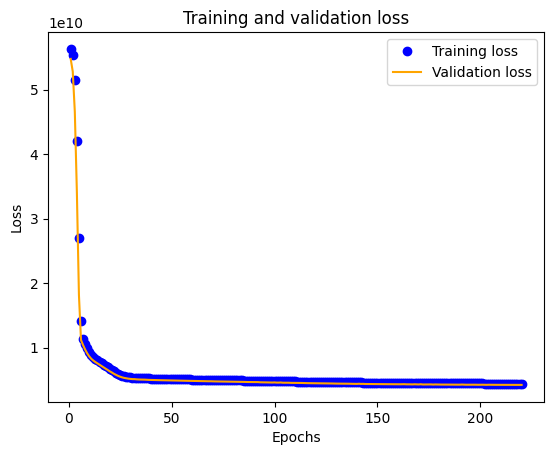

In [27]:
# let's see the training and validation accuracy by epoch
history_dict = history.history
loss_values = history_dict['loss'] # you can change this
val_loss_values = history_dict['val_loss'] # you can also change this
epochs = range(1, len(loss_values) + 1) # range of X (no. of epochs)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'orange', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

This model seemed to converge around 50 epochs without dropout.

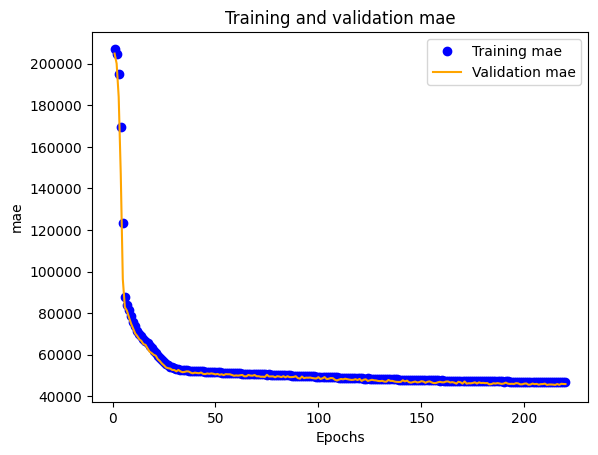

In [28]:
# let's see the training and validation accuracy by epoch
history_dict = history.history
loss_values = history_dict['mae'] # you can change this
val_loss_values = history_dict['val_mae'] # you can also change this
epochs = range(1, len(loss_values) + 1) # range of X (no. of epochs)
plt.plot(epochs, loss_values, 'bo', label='Training mae')
plt.plot(epochs, val_loss_values, 'orange', label='Validation mae')
plt.title('Training and validation mae')
plt.xlabel('Epochs')
plt.ylabel('mae')
plt.legend()
plt.show()

## Scatterplots of actual vs. predicted

  1/511 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step

 49/511 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

102/511 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

159/511 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step

213/511 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step

269/511 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step

322/511 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step

378/511 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step

442/511 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step

503/511 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step

511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


  1/128 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

 54/128 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step

110/128 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


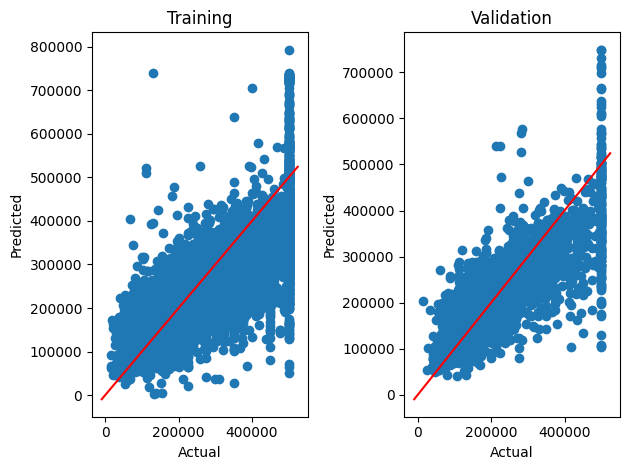

In [29]:
# scatterplot of actual vs. pred
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# this makes the individual subplots
# Training Results
axes[0].scatter(x=y_train, y=model.predict(X_train)) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted",  fontsize=10)
axes[0].set_title("Training")
# add 45 deg line
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')
# Validation Results
axes[1].scatter(x=y_test, y=model.predict(X_test)) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted",  fontsize=10)
axes[1].set_title("Validation")
# add 45 deg line
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# show the plot
plt.show()

## Model Evaluation Metrics

In [30]:
# metrics
pred = model.predict(X_test)
pred

trainpreds = model.predict(X_train)

from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_train, trainpreds)) # train
print(mean_absolute_error(y_test, pred)) # test

  1/128 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step

 55/128 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step

119/128 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


  1/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step

 49/511 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

105/511 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step

168/511 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step 

223/511 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step

276/511 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step

331/511 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step

395/511 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step

448/511 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step

504/511 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step

511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 994us/step


46523.66555113648


45507.99394421336


🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 10 (M2.2) - Dropout

- Dropout = randomly switch off nodes during training. The bank-teller analogy: rotate the staff so no single teller can run a scam - no node becomes indispensable.
- It's the random-forest idea inside one network: different subnetwork each batch, all neurons at inference.
- Typical 0.1-0.5, placed AFTER a Dense layer. It is a hyperparameter - tune it.
- The 0.9 demo: model gets stuck predicting the mean. Too much regularization = a model too crippled to learn.
-->

# Dropout
Read this: http://primo.ai/index.php?title=Dropout

Adding dropout layers between the dense layers is a great idea! Maybe our model will fit more gradually and will learn the dataset more completely.


Try values of 0.1 vs. 0.5 vs. 0.9 for dropout - how does the model do? You can copy and paste this above and re-run.



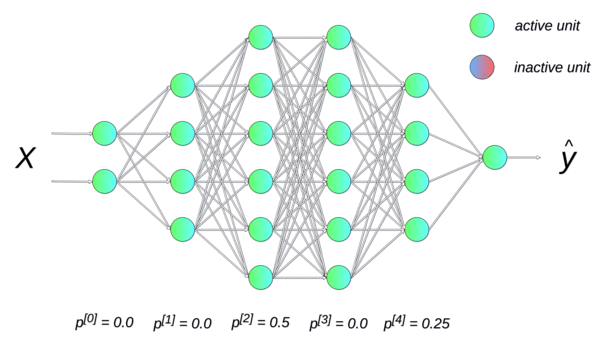

A value of 0.5 turns off half of the nodes in the hidden unit - which means half of the information makes it to the next layer, and only up to half of the weights will be updated! Similarly, a dropout value of 0.25 turns off 25% of the information. A value of 0 means there is no dropout.

In [31]:
# now go back up and add dropout to your model and watch
# how the learning curve changes!

# previous model had MAE of 35000 and took 185 epochs
# how does dropout (0.2) help? MAE of 37000 and took 170 epochs... maybe a more gradual learning curve?
# how does dropout (0.9) help? MAE of 45000 and took 238 epochs... more sophistication didn't help our model -
# could have just stuck with the simpler architecture.
# you may get different results due to different random weights at initialization.

In [32]:
# resets names in the model summary
from keras import backend as K
K.clear_session()

In [33]:
# build the model!
model = Sequential()
model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu')) # (features,)
model.add(Dropout(0.5)) # specify a percentage between 0 and 0.5
model.add(Dense(25, activation='relu'))
model.add(Dropout(0.5)) # specify a percentage between 0 and 0.5
model.add(Dense(10, activation='relu'))
model.add(Dropout(0.5)) # specify a percentage between 0 and 0.5
model.add(Dense(1, activation='linear')) # output node
model.summary() # see what your model looks like

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,246 (8.77 KB)

 Trainable params: 2,246 (8.77 KB)

 Non-trainable params: 0 (0.00 B)

Feel free to try updating the architecture at the top with dropout and patience (early stopping) and see how low of an MAE you can get!

# Dropout showdown: watch the learning curve change

You've now seen the model WITHOUT dropout and the model WITH dropout. Let's put them side by side and make the effect impossible to miss.

Same data. Same architecture (50 → 25 → 10 → 1). Same number of epochs. The ONLY thing that changes is the dropout rate: **0.0, 0.2, 0.5**.

One important trick for a fair fight: we turn early stopping OFF and train every model for the same fixed number of epochs. If we let early stopping decide, each model would train for a different length and the curves wouldn't be comparable... apples to apples!

In [34]:
# three identical models - only the dropout rate changes
import keras
keras.utils.set_random_seed(5509) # reproducibility! you know the drill

def build_and_fit(rate, epochs=100):
    model = Sequential()
    model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu'))
    if rate > 0: model.add(Dropout(rate))
    model.add(Dense(25, activation='relu'))
    if rate > 0: model.add(Dropout(rate))
    model.add(Dense(10, activation='relu'))
    if rate > 0: model.add(Dropout(rate))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    hist = model.fit(X_train, y_train,
                     validation_data=(X_test, y_test),
                     epochs=epochs, batch_size=50,
                     shuffle=True, verbose=0) # verbose=0 keeps the notebook clean
    print(f'dropout={rate} ... done ({epochs} epochs)')
    return model, hist

rates = [0.0, 0.2, 0.5]
results = {r: build_and_fit(r) for r in rates}

dropout=0.0 ... done (100 epochs)


dropout=0.2 ... done (100 epochs)


dropout=0.5 ... done (100 epochs)


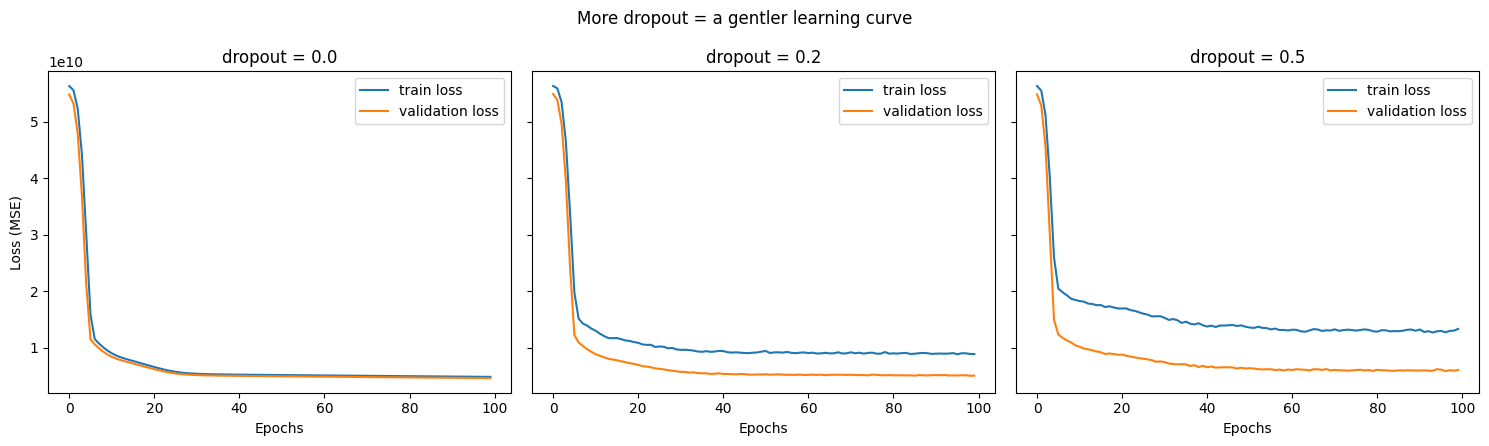

In [35]:
# the learning curves, side by side - SAME y-axis so your eye can't be fooled
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, r in zip(axes, rates):
    hist = results[r][1]
    ax.plot(hist.history['loss'], label='train loss')
    ax.plot(hist.history['val_loss'], label='validation loss')
    ax.set_title(f'dropout = {r}')
    ax.set_xlabel('Epochs')
    ax.legend()
axes[0].set_ylabel('Loss (MSE)')

plt.suptitle('More dropout = a gentler learning curve')
plt.tight_layout()
plt.show()

In [36]:
# ...and the error metrics - are the models actually all that different?
from sklearn.metrics import mean_absolute_error

rows = []
for r in rates:
    m = results[r][0]
    tr = mean_absolute_error(y_train, m.predict(X_train, verbose=0))
    te = mean_absolute_error(y_test,  m.predict(X_test,  verbose=0))
    rows.append({'dropout': r,
                 'train MAE': round(tr, 2),
                 'test MAE': round(te, 2),
                 'gap (test - train)': round(te - tr, 2)})

pd.DataFrame(rows)

,dropout,train MAE,test MAE,gap (test - train)
0,0.0,49337.06,48608.06,-729.00
1,0.2,50006.28,49072.21,-934.07
2,0.5,53521.47,52432.20,-1089.28


💡 See it? **More dropout = a gentler, more cautious learning curve.** With dropout on, part of the network is switched off during every training batch, so the model descends more carefully - and the wiggles smooth out as the rate goes up.

Now look at the table... the test MAEs land in the same neighborhood, and the train/test gaps are TINY in all three models (even slightly negative - test a hair better than train, which happens and is nothing to chase). Translation: this little network on this much data was never overfitting in the first place, so dropout had nothing to rescue - it just made training more careful. That is exactly the point: **dropout is insurance, not magic.** On bigger networks, trained longer, on less data - when the validation curve starts drifting AWAY from the training curve - that is when this insurance pays out.

**On Your Own:** add dropout = 0.9 to the showdown and re-run. Watch the model get stuck predicting the mean - too much regularization and there isn't enough network left to learn anything!

# On Your Own
Remember that there are no trainable parameters in the dropout layer!